# Transcode Pilot Analysis

Comprehensive analysis of the translon pilot ORF-calling results.
All counts use `COUNT(DISTINCT feature_key)` to represent unique genomic ORF structures.
Filters applied throughout: `qc_status = 'pass'`, `sample_id NOT GLOB '*_fastq'`,
`source_feature_class IN ('cds', 'non_cds')`.

In [69]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is None:
        matplotlib.use('Agg')
    else:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
# Prefers local SCP'd copy; falls back to HPC mount if not present
HPC_DB   = Path("/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite")
LOCAL_DB = Path("/Users/jackt/translon_db/translon_db_rebuild.sqlite")
DB = LOCAL_DB if LOCAL_DB.exists() else HPC_DB

OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────────────
TOOL_ORDER = ["PRICE", "RiboTIE", "ORFQuant", "iRibo", "RibORF2"]
CLS_ORDER  = ["cds", "non_cds"]
CLS_LABELS = {"cds": "CDS", "non_cds": "Non-CDS"}

TOOL_COLORS = {
    "PRICE":    "#4C72B0",
    "RiboTIE":  "#DD8452",
    "ORFQuant": "#55A868",
    "iRibo":    "#C44E52",
    "RibORF2":  "#8172B2",
}
CLS_COLORS = {"cds": "#2196F3", "non_cds": "#FF9800"}

# ── Sample → cell-type mapping ─────────────────────────────────────────────
SAMPLE_CELL_TYPE = {
    # Pancreas (7)
    "SRR11005875_to_79":  "pancreas",
    "SRR11005880_to_84":  "pancreas",
    "SRR11005885_to_89":  "pancreas",
    "SRR11005890_to_94":  "pancreas",
    "SRR11005895_to_99":  "pancreas",
    "SRR11005900_to_04":  "pancreas",
    "Ribo_Pancreas_pooled": "pancreas",
    # Fibroblast (11)
    "SRR15513179":        "fibroblast",
    "SRR15513180":        "fibroblast",
    "SRR15513181":        "fibroblast",
    "SRR15513182":        "fibroblast",
    "Fib_24_45m":         "fibroblast",
    "Fib_24_bsl":         "fibroblast",
    "Fib_27_45m":         "fibroblast",
    "Fib_27_bsl":         "fibroblast",
    "Fib_41_45m":         "fibroblast",
    "Fib_41_bsl":         "fibroblast",
    "Ribo_Fib_pooled":    "fibroblast",
    # Endothelial (7)
    "SRR15513197":        "endothelial",
    "SRR15513198_GENELAB1026": "endothelial",
    "SRR15513199":        "endothelial",
    "SRR15513200":        "endothelial",
    "SRR15513201":        "endothelial",
    "SRR15513202_GENELAB1143": "endothelial",
    "Ribo_EC_pooled":     "endothelial",
}

POOLED_SAMPLES = {"Ribo_Pancreas_pooled", "Ribo_Fib_pooled", "Ribo_EC_pooled"}

BASE_FILTER = "qc_status = 'pass' AND sample_id NOT GLOB '*_fastq' AND source_feature_class IN ('cds', 'non_cds')"

print(f"DB path: {DB}")
print(f"DB exists: {DB.exists()}")

DB path: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite
DB exists: True


## Load data

Build deduplicated feature tables and per-sample counts from the SQLite database.

In [70]:
con = sqlite3.connect(DB)

# ── Unique feature table: one row per (tool × feature_key) ─────────────────
feats = pd.read_sql_query(f"""
    SELECT source_tool,
           source_feature_class AS cls,
           feature_key,
           bed_chrom,
           bed_start,
           bed_end,
           bed_strand,
           block_count,
           spliced_length_nt,
           start_codon_class,
           terminal_codon_class
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, source_feature_class, feature_key
""", con)

# Normalise tool names to match TOOL_ORDER
feats['source_tool'] = feats['source_tool'].str.strip()

print(f"feats shape: {feats.shape}")
print("\nPer-tool counts:")
print(feats.groupby(['source_tool', 'cls'])['feature_key'].count().unstack(fill_value=0))

# ── Reference CDS table ────────────────────────────────────────────────────
ref_cds = pd.read_sql_query("""
    SELECT transcript_id, gene_id, gene_name,
           bed_chrom, bed_start, bed_end, bed_strand,
           block_count, block_sizes, block_starts,
           spliced_length_nt, feature_key
    FROM reference_cds
""", con)
print(f"\nreference_cds shape: {ref_cds.shape}")

# ── Per-sample counts ──────────────────────────────────────────────────────
per_sample = pd.read_sql_query(f"""
    SELECT source_tool,
           sample_id,
           source_feature_class AS cls,
           COUNT(DISTINCT feature_key) AS n_features
    FROM translons
    WHERE {BASE_FILTER}
    GROUP BY source_tool, sample_id, source_feature_class
""", con)

print(f"\nper_sample shape: {per_sample.shape}")
print(per_sample.head())

con.close()

feats shape: (822015, 11)

Per-tool counts:
cls             cds  non_cds
source_tool                 
ORFQuant      78603    33568
PRICE        133869    33189
RibORF2      220749   169724
RiboTIE       83671    16037
iRibo         16578    36027

reference_cds shape: (112304, 12)

per_sample shape: (250, 4)
  source_tool   sample_id      cls  n_features
0    ORFQuant  Fib_24_45m      cds       16715
1    ORFQuant  Fib_24_45m  non_cds        2375
2    ORFQuant  Fib_24_bsl      cds       16423
3    ORFQuant  Fib_24_bsl  non_cds        2214
4    ORFQuant  Fib_27_45m      cds       15327


## CDS Recall Analysis

How well does each tool recover the ~94k GENCODE reference CDS at multiple stringency levels?

Reference CDS: 94,931 unique feature_keys
PRICE: exact=14,425 (15.2%) | stop=39,713 (41.8%) | start=45,223 (47.6%) | near-miss=25,487 (26.8%)
RiboTIE: exact=42,717 (45.0%) | stop=55,629 (58.6%) | start=57,442 (60.5%) | near-miss=46,141 (48.6%)
ORFQuant: exact=37,028 (39.0%) | stop=52,562 (55.4%) | start=64,259 (67.7%) | near-miss=42,464 (44.7%)
iRibo: exact=16,578 (17.5%) | stop=37,121 (39.1%) | start=55,236 (58.2%) | near-miss=26,161 (27.6%)
RibORF2: exact=54,934 (57.9%) | stop=67,325 (70.9%) | start=70,133 (73.9%) | near-miss=60,179 (63.4%)


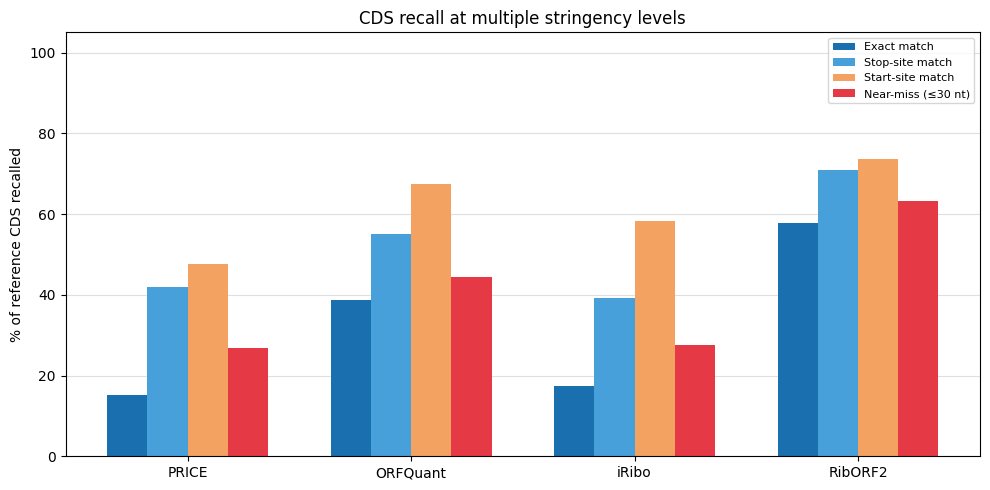

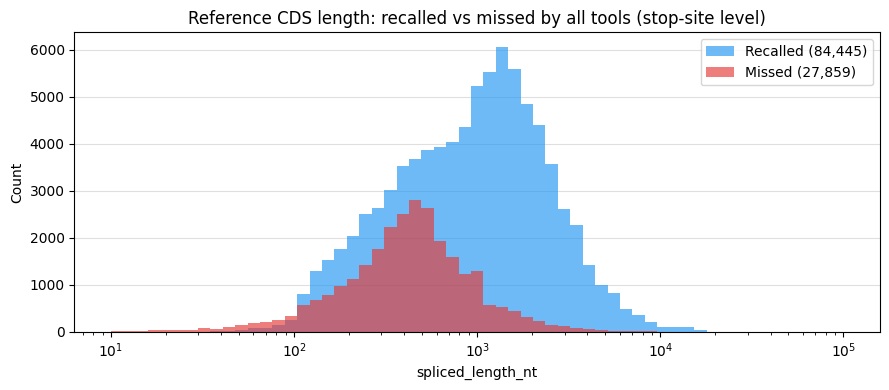

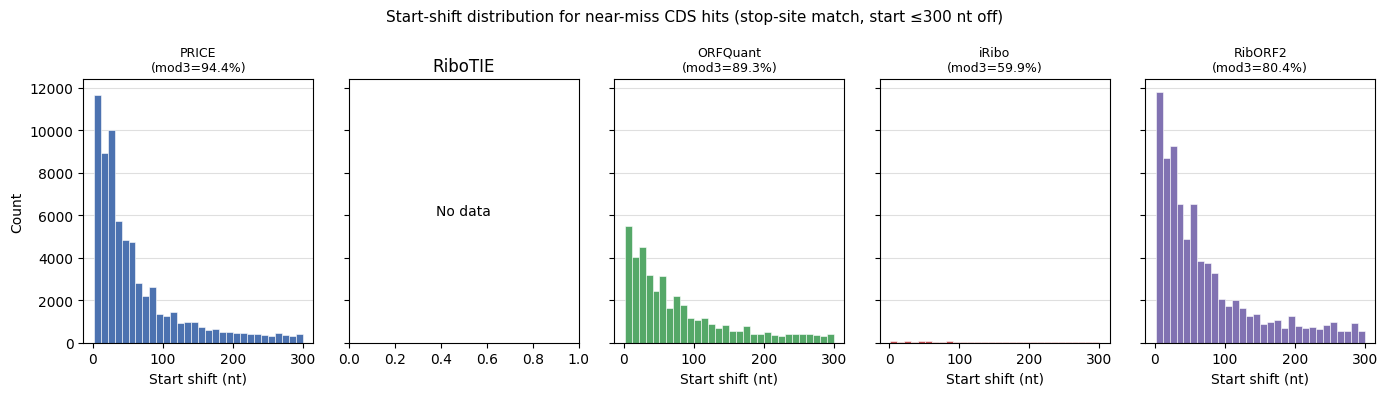

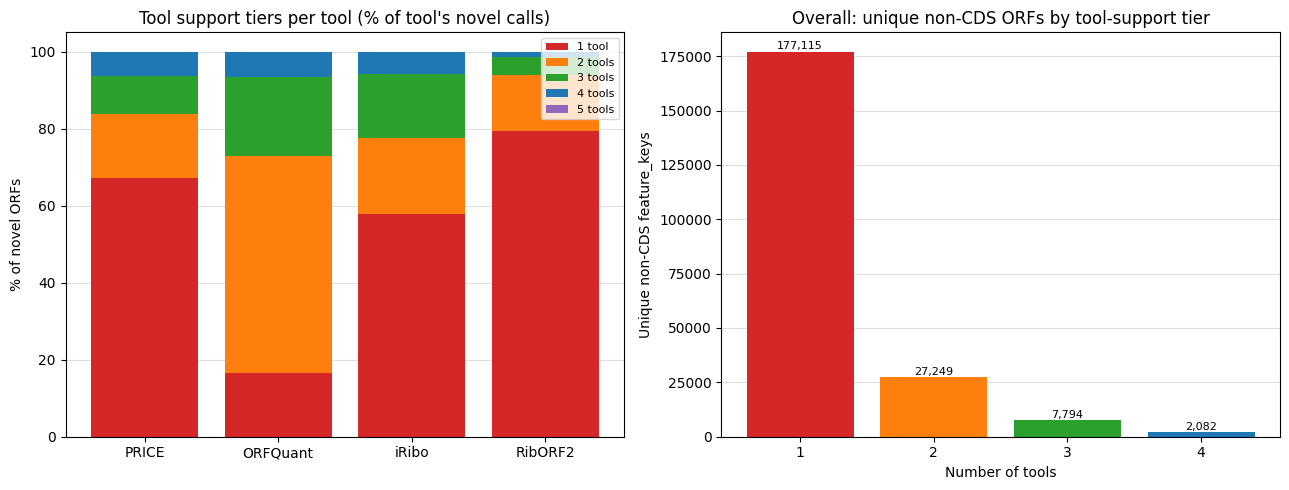

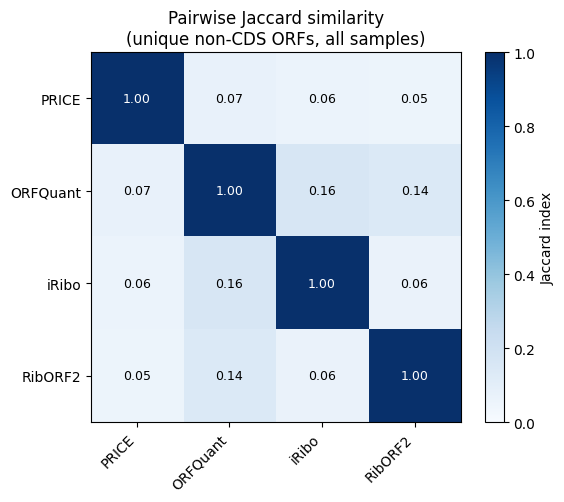

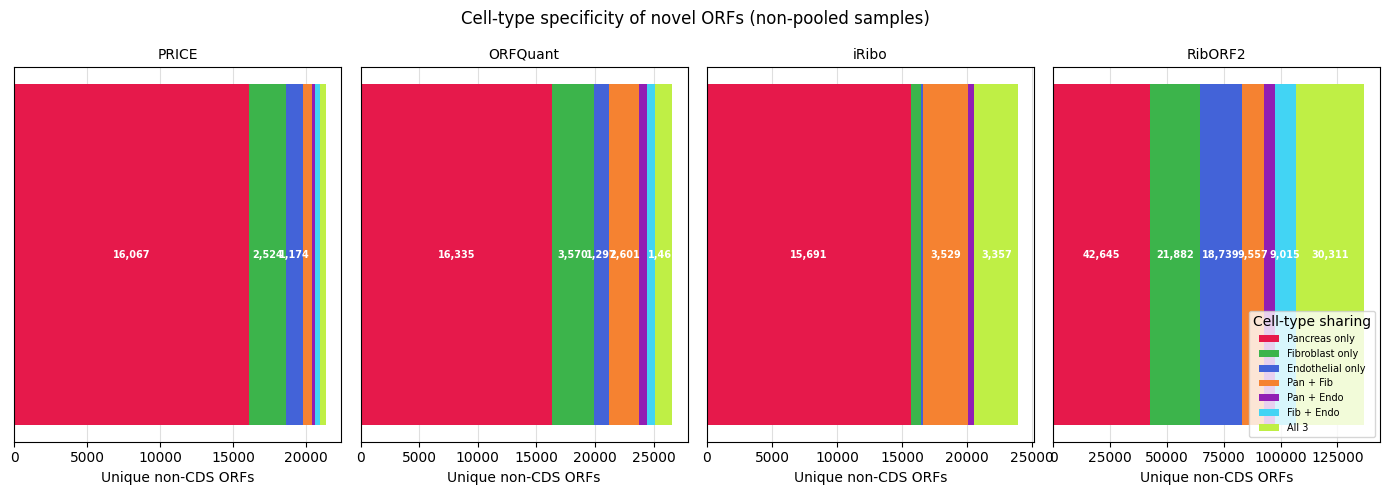

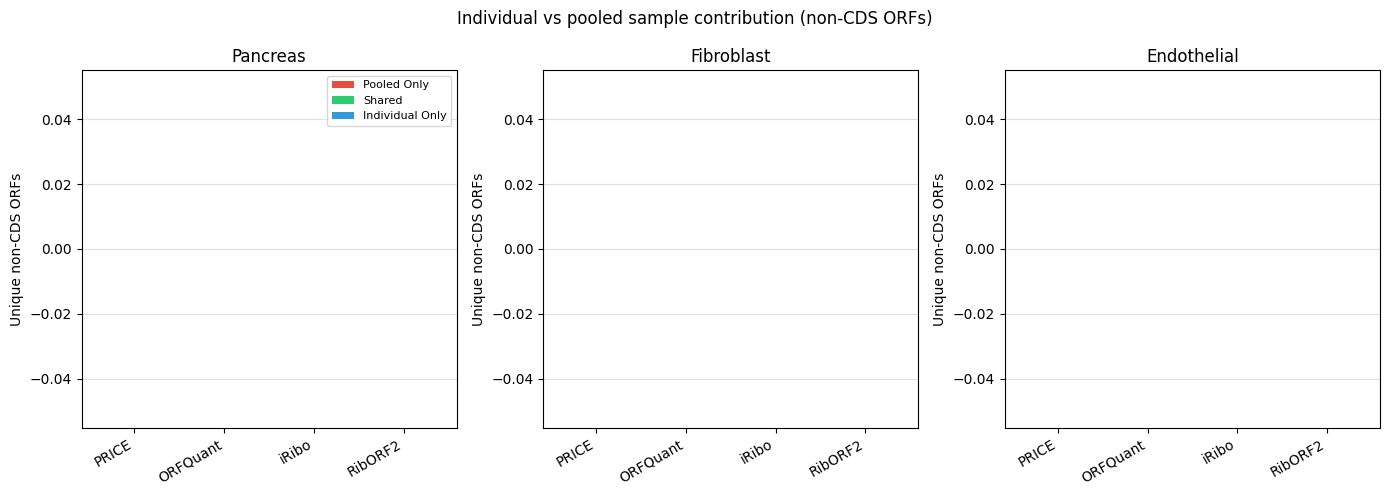

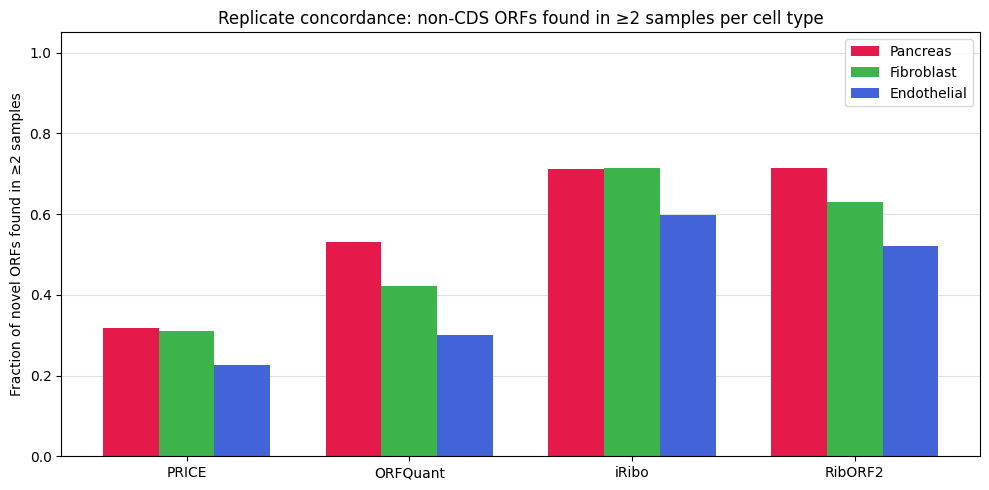

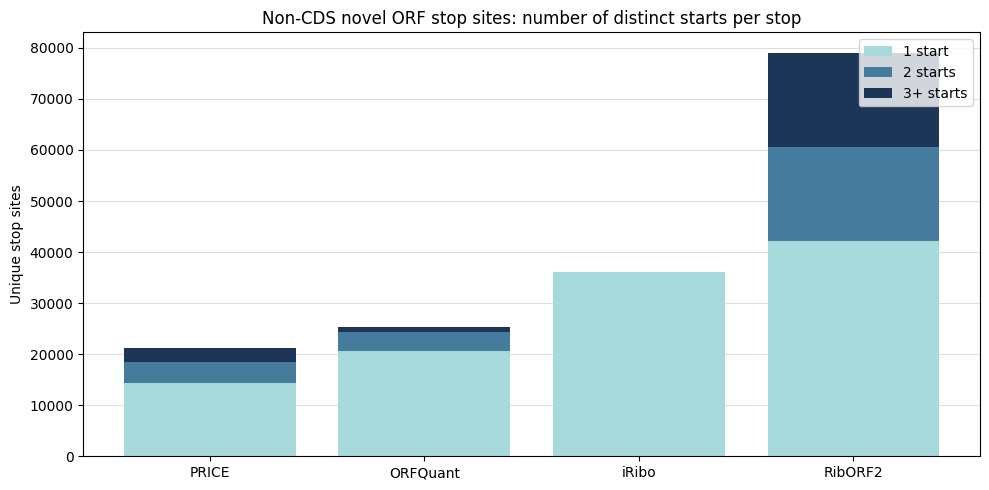

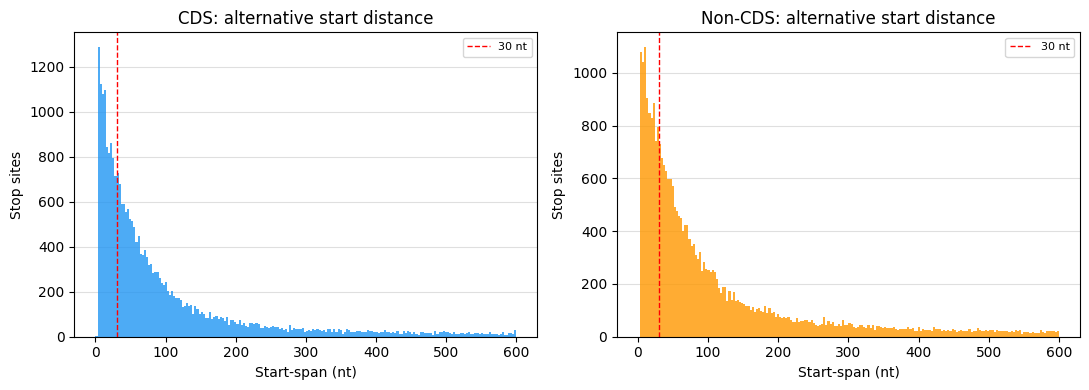

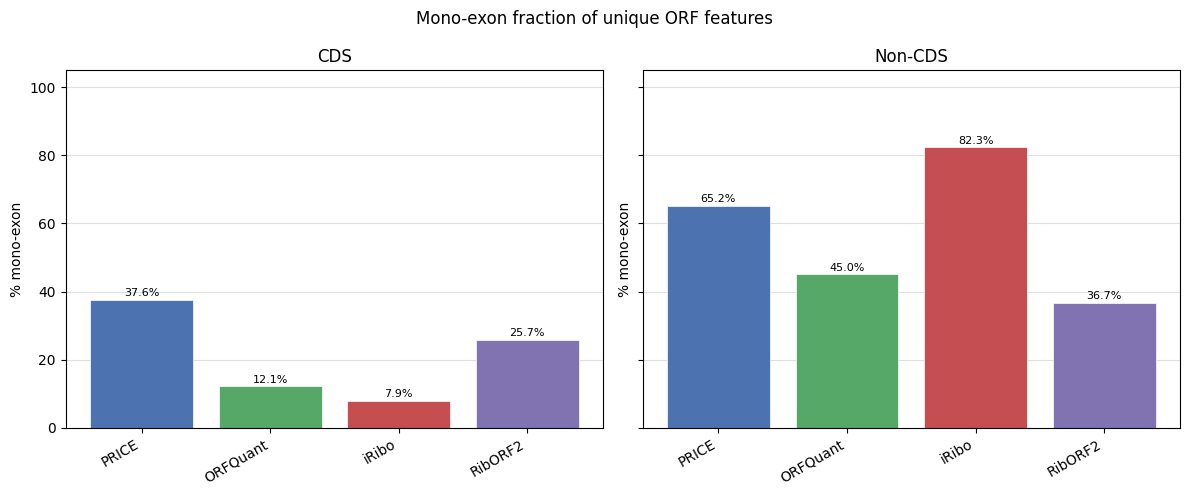

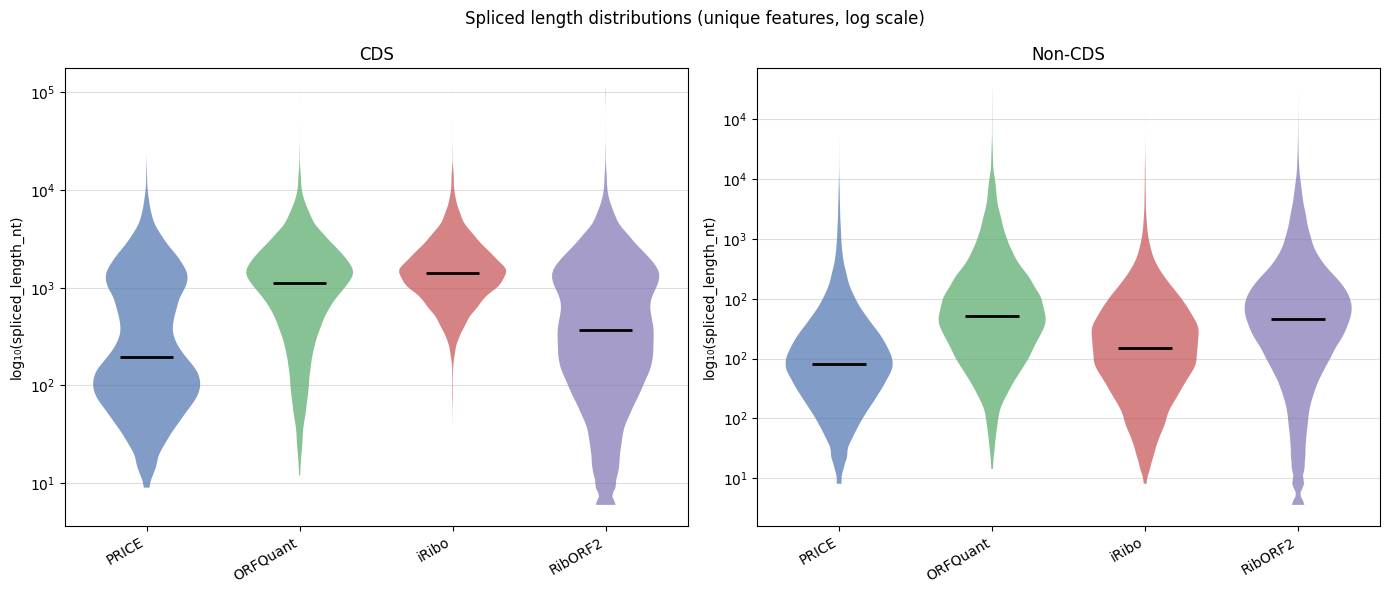

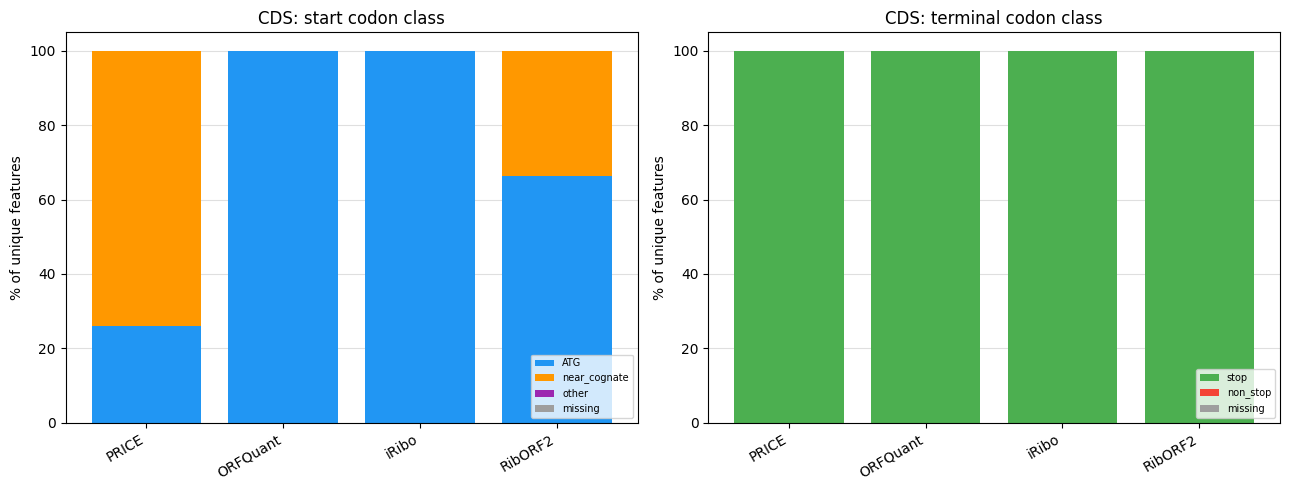

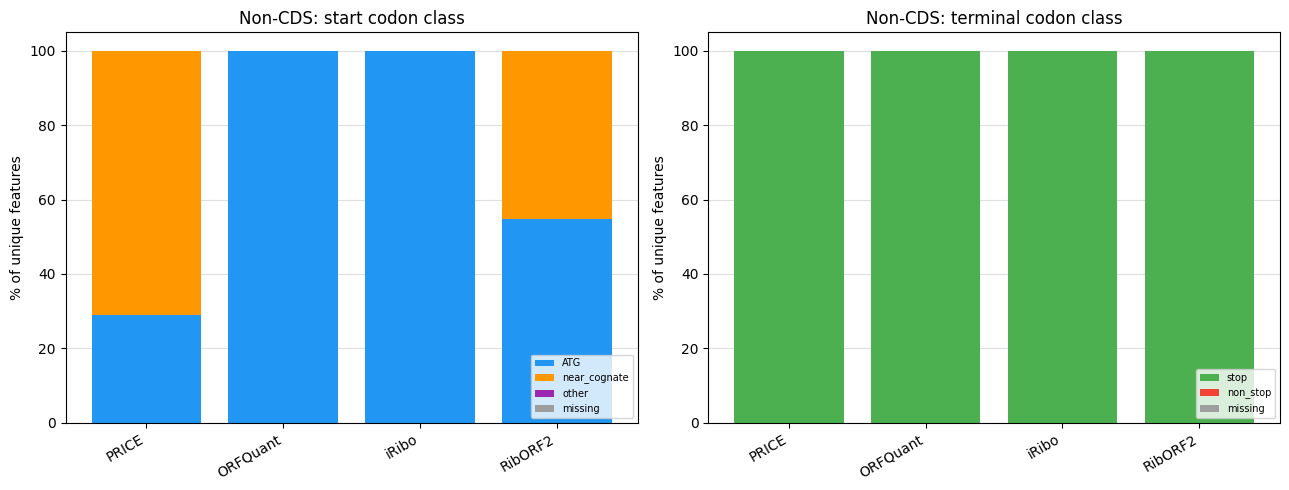

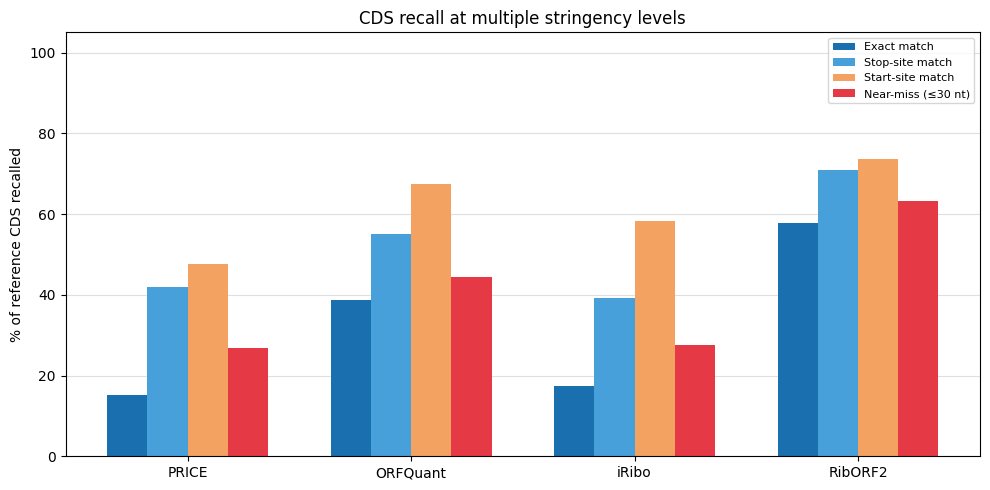

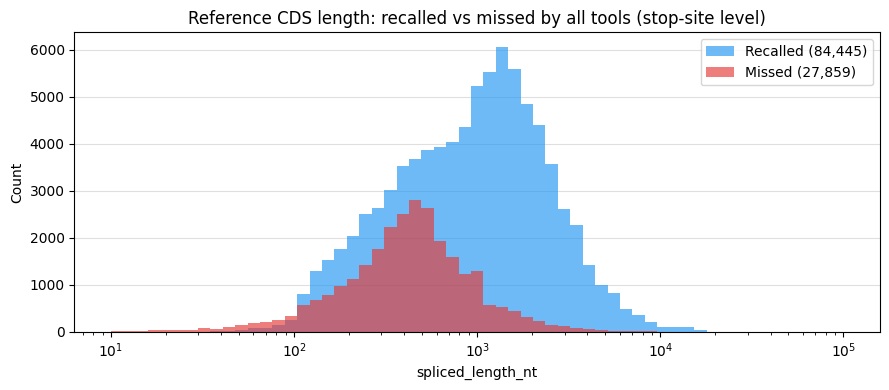

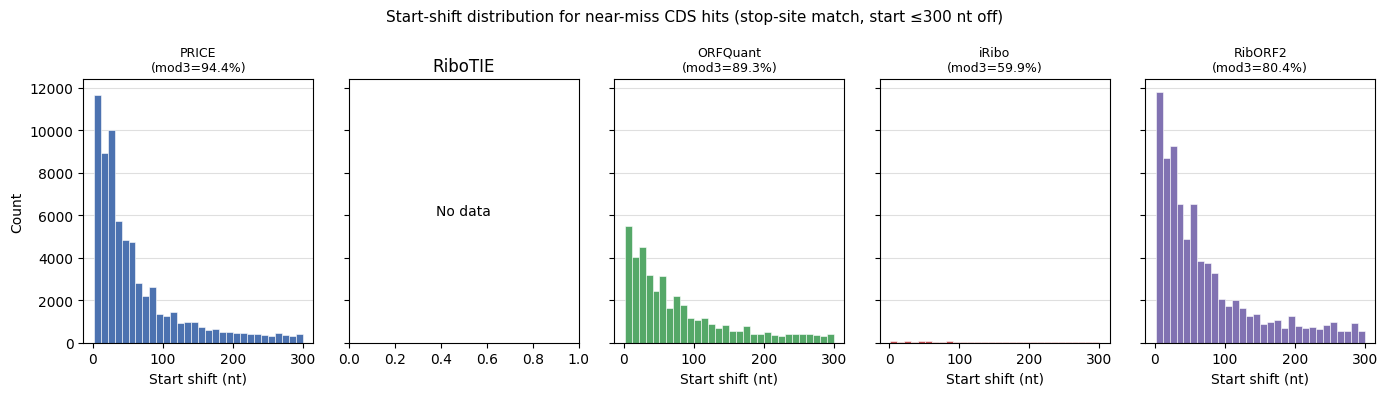

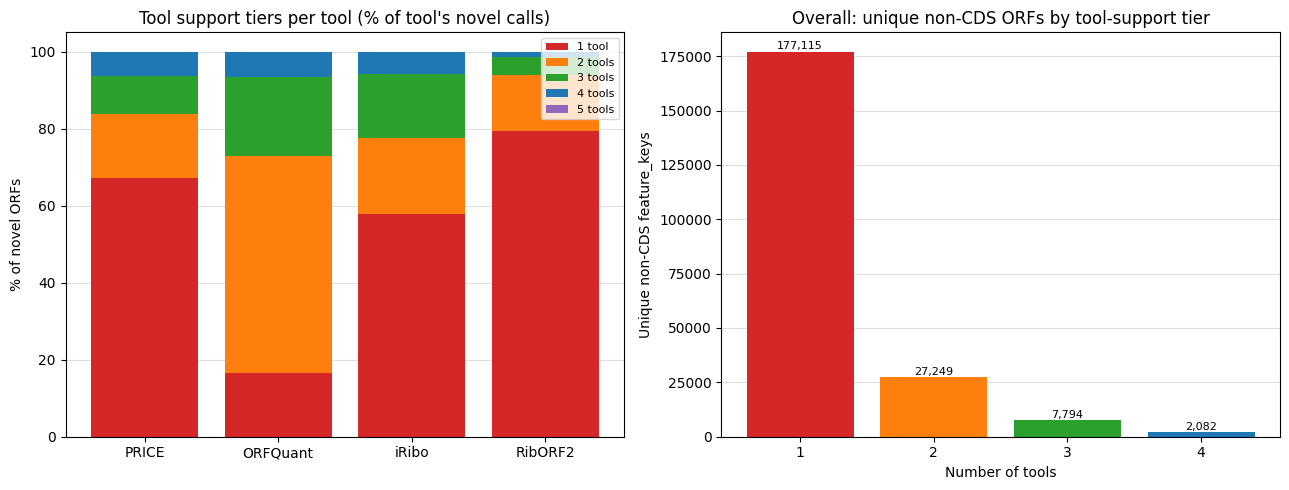

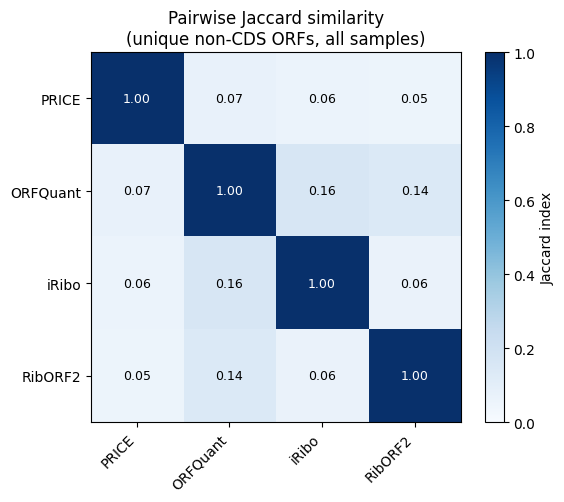

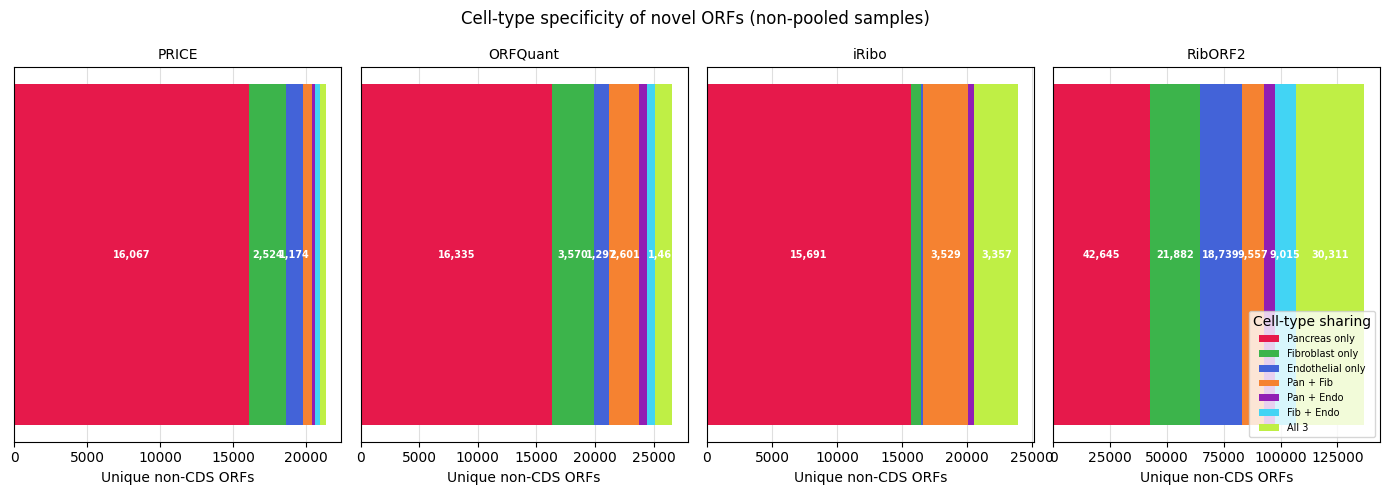

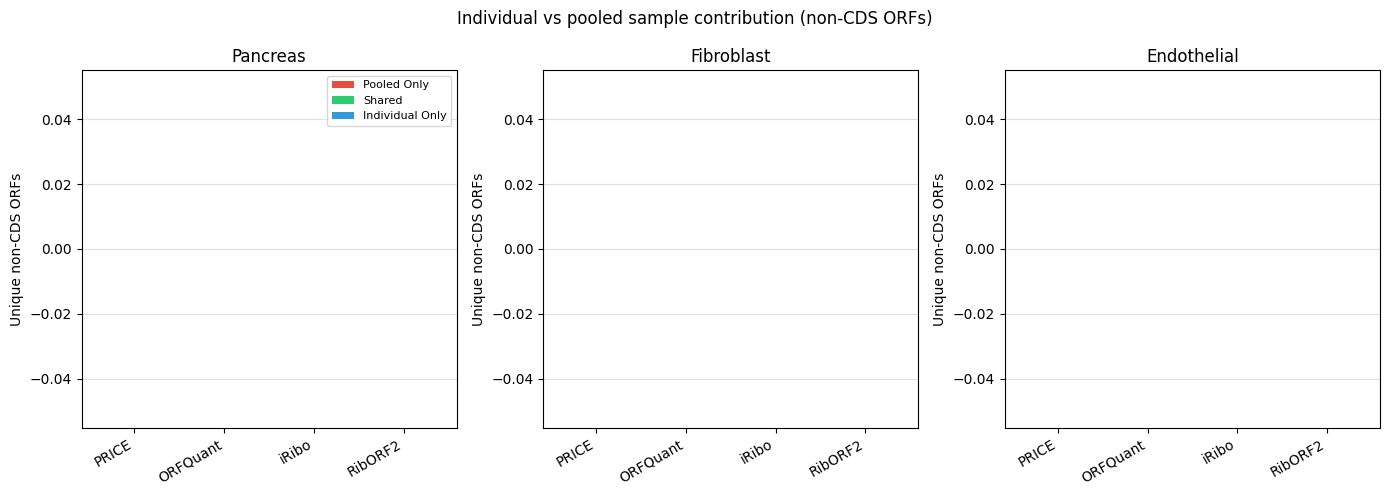

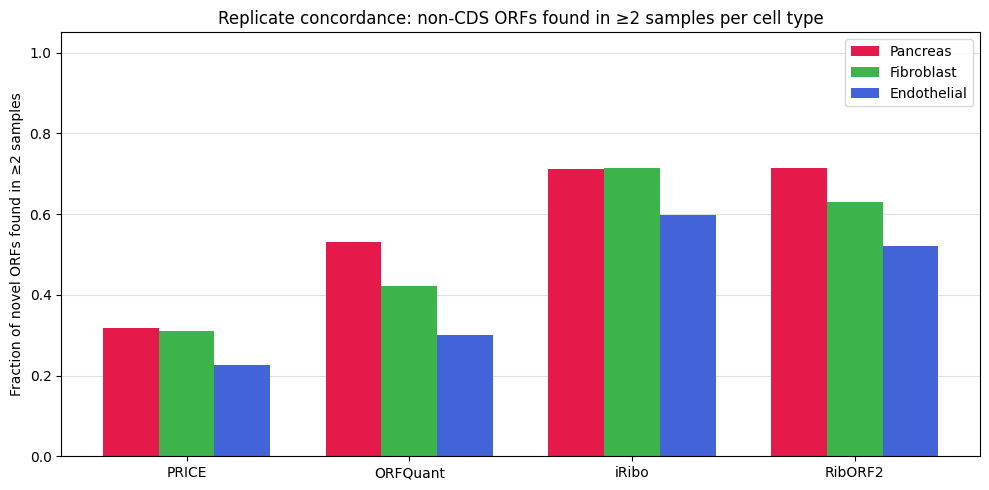

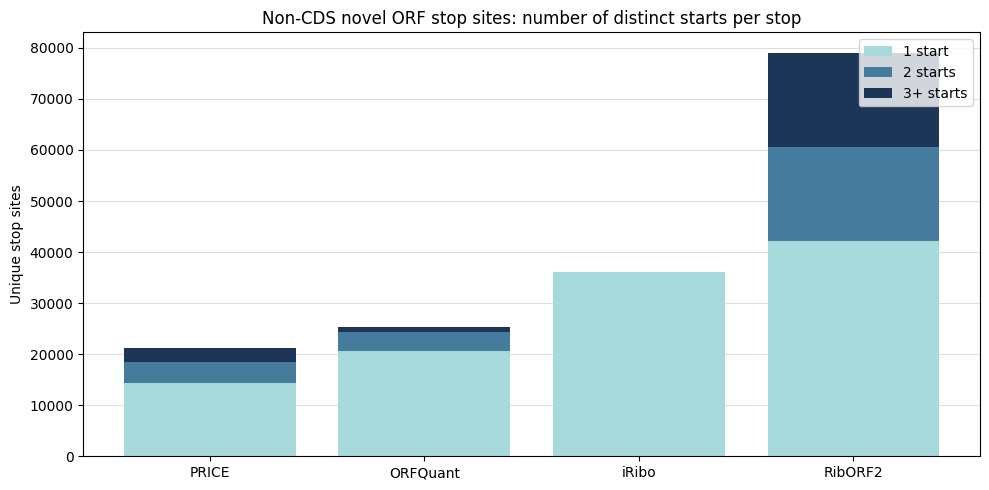

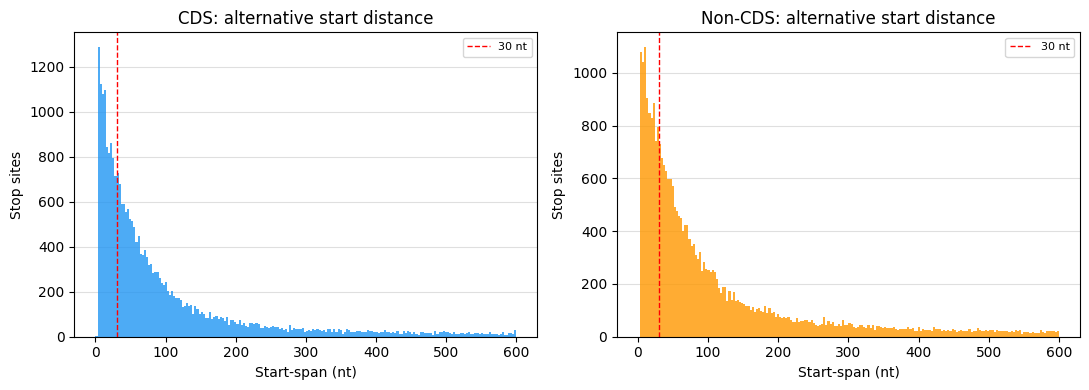

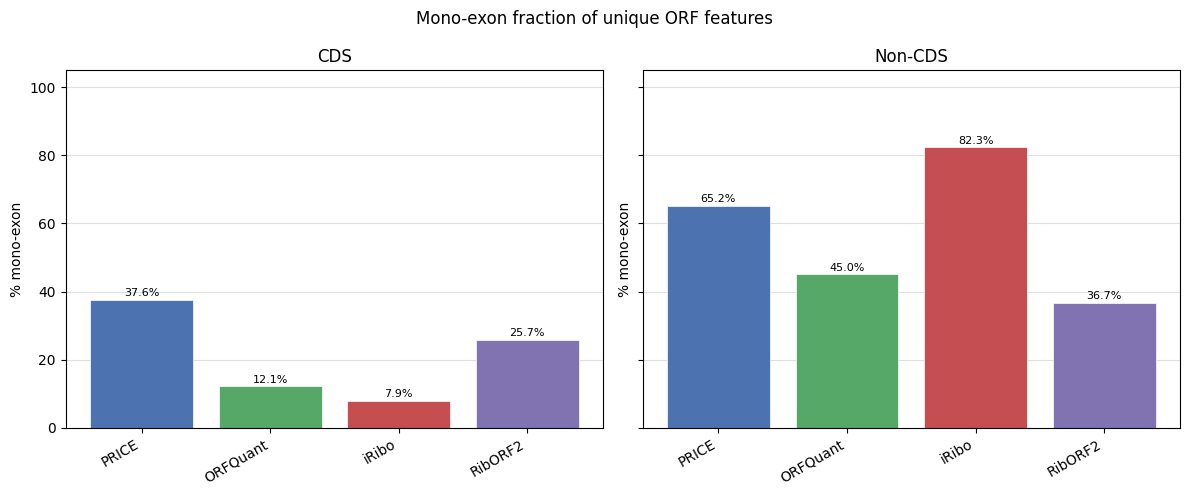

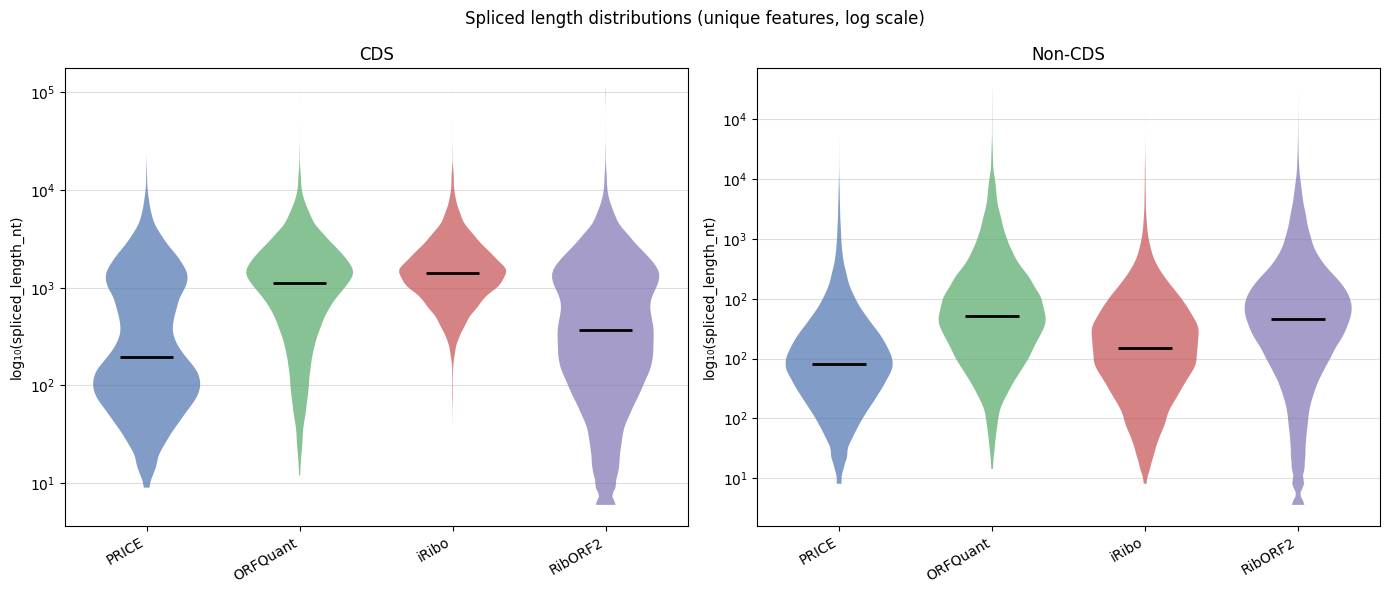

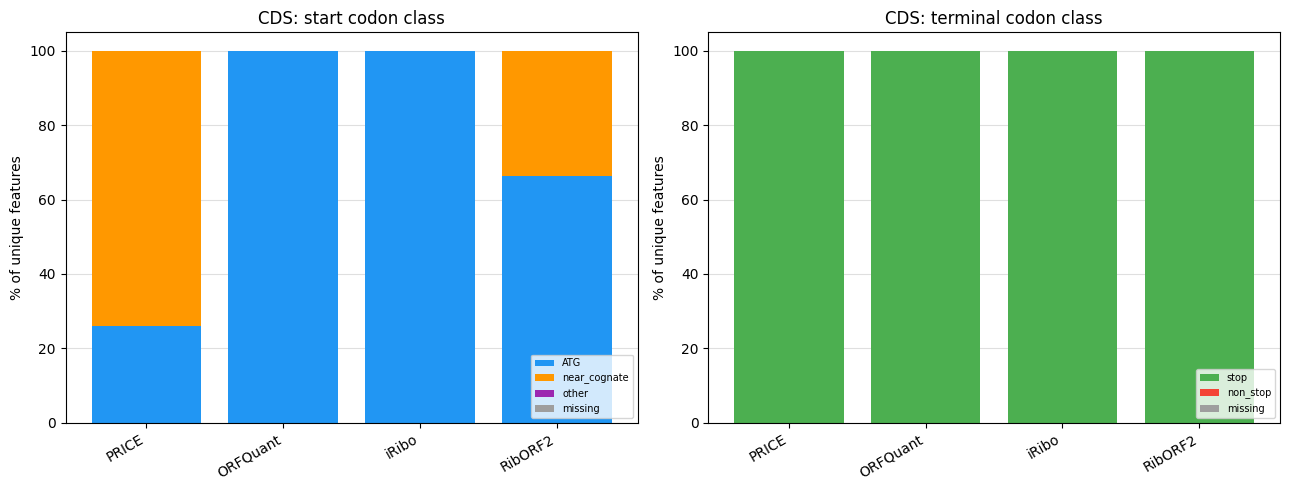

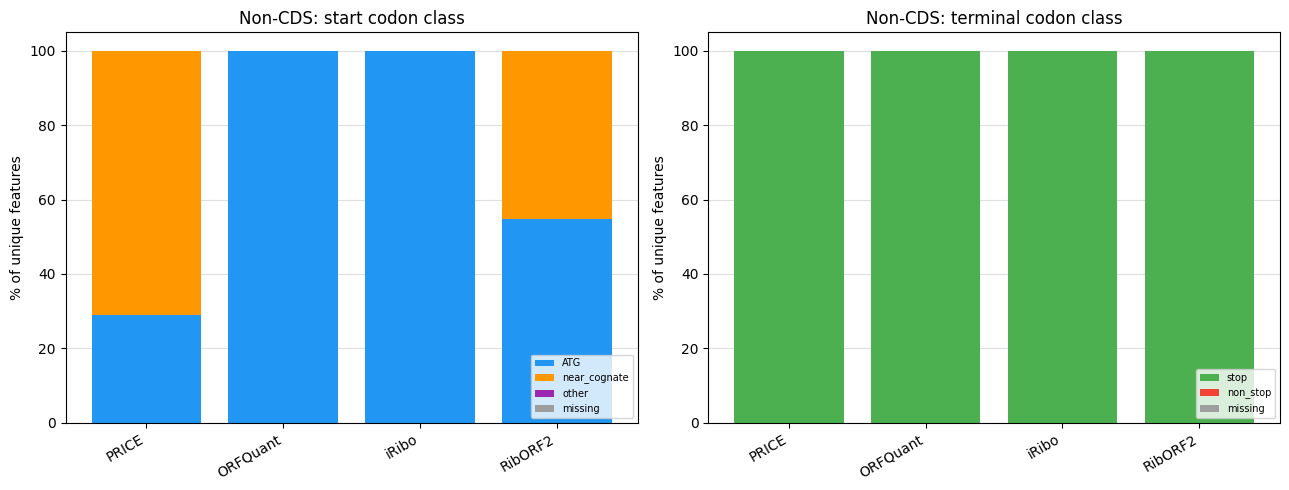

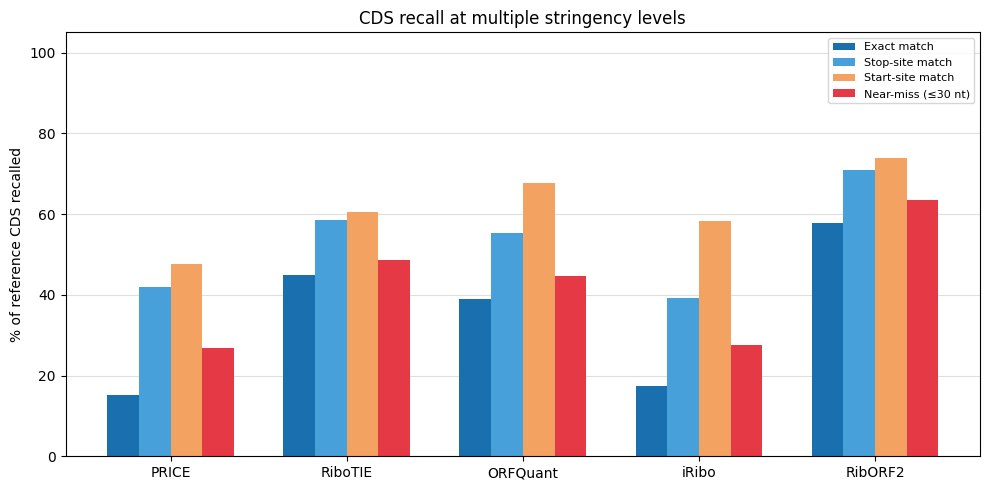

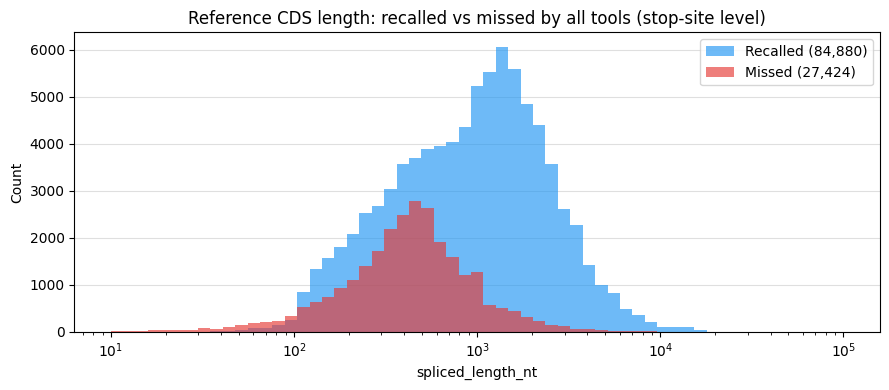

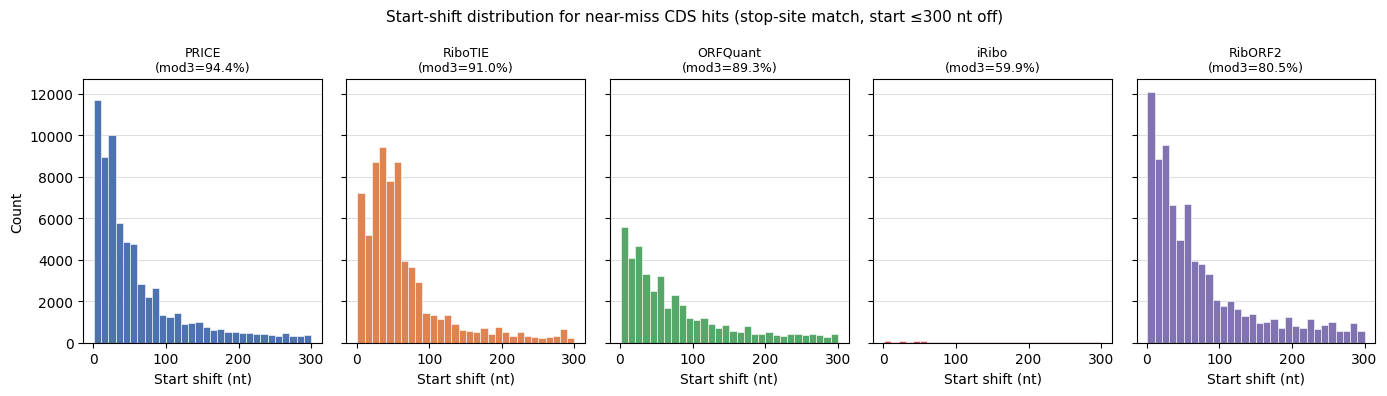

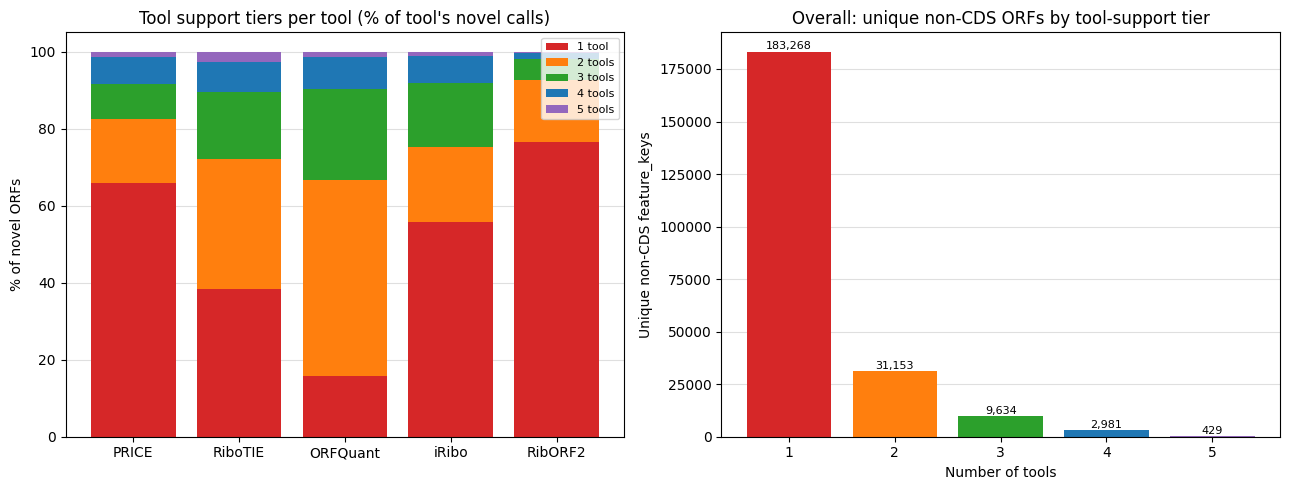

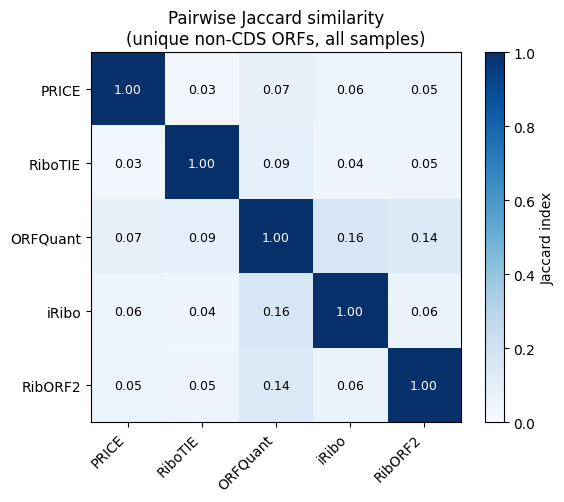

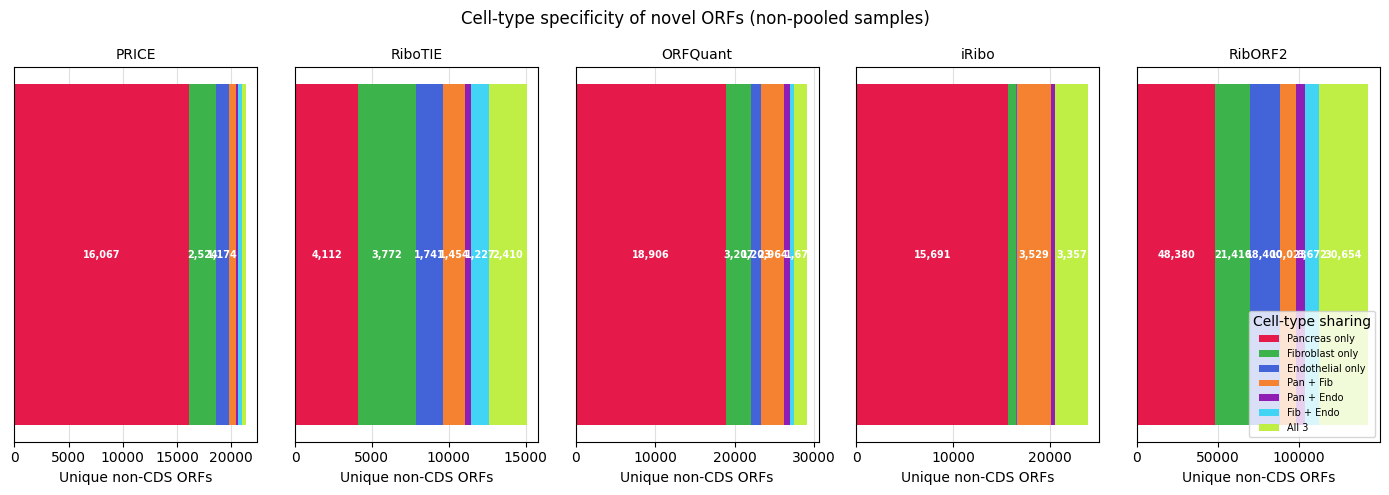

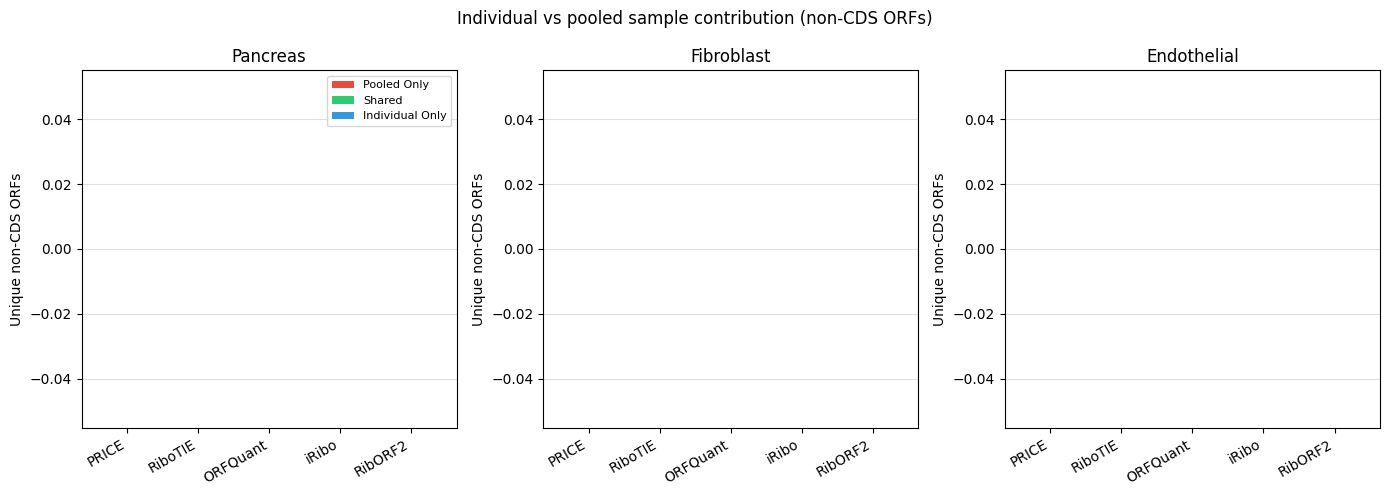

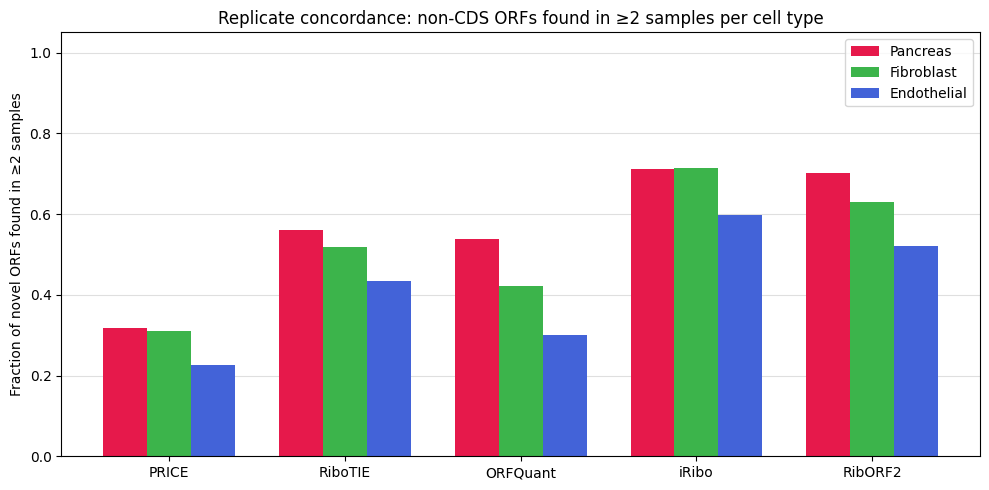

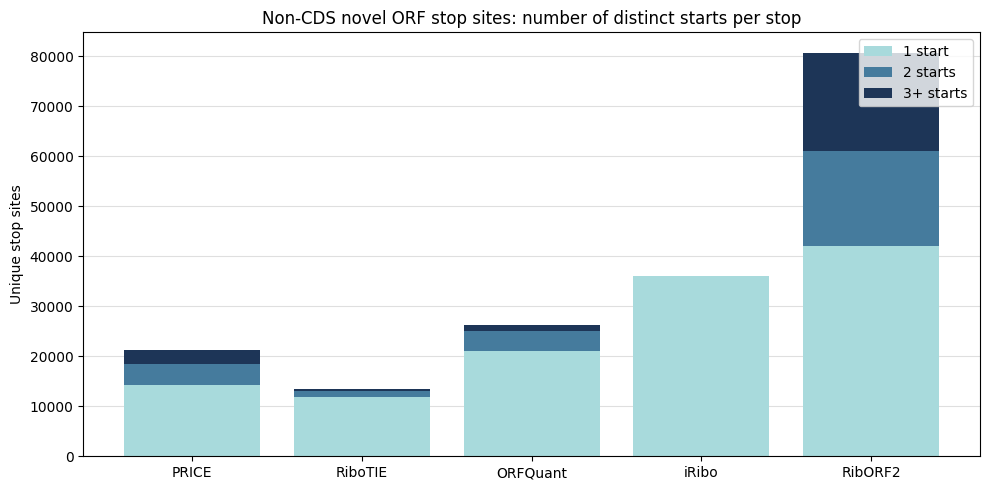

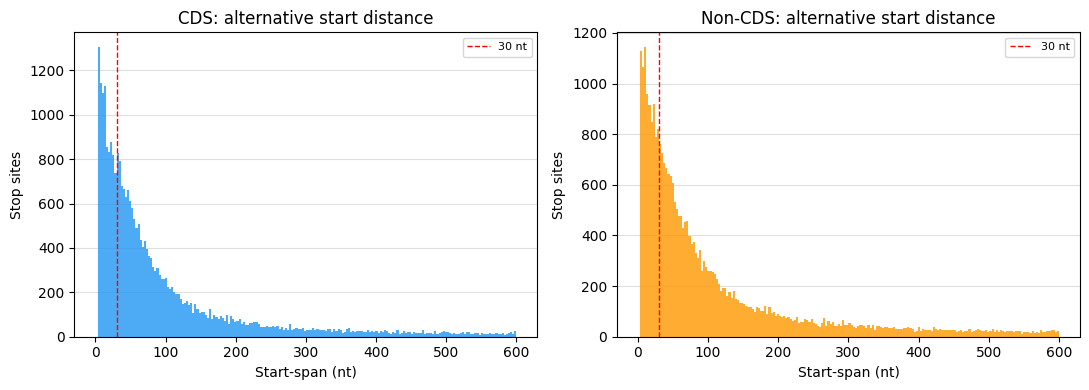

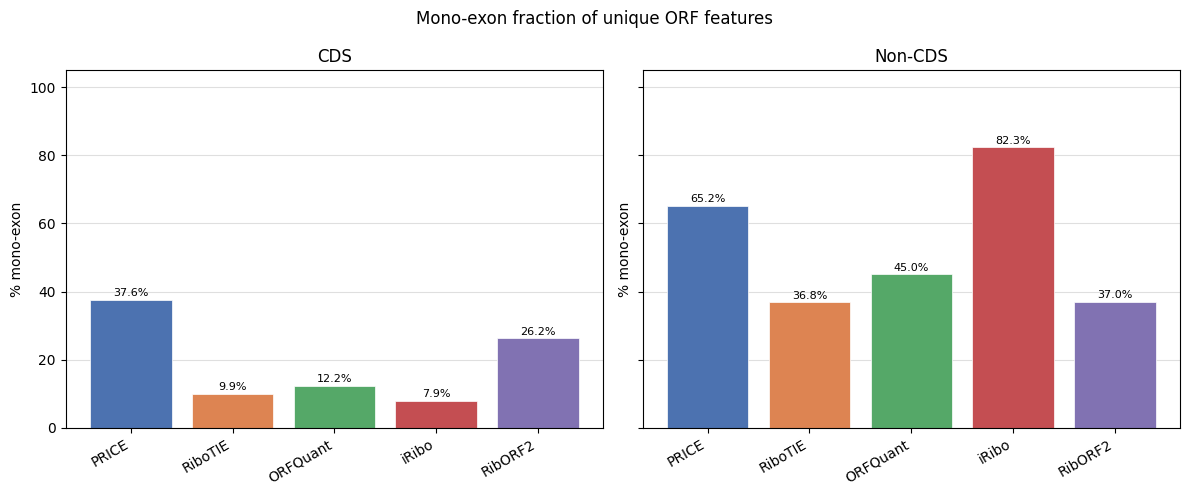

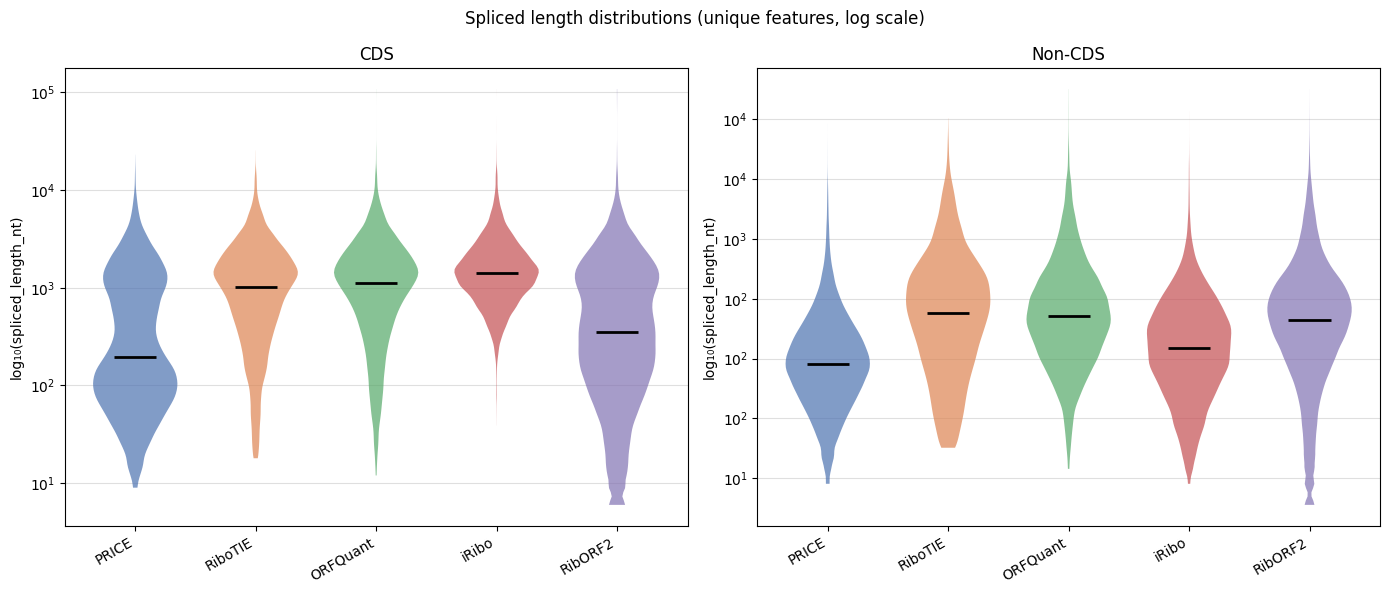

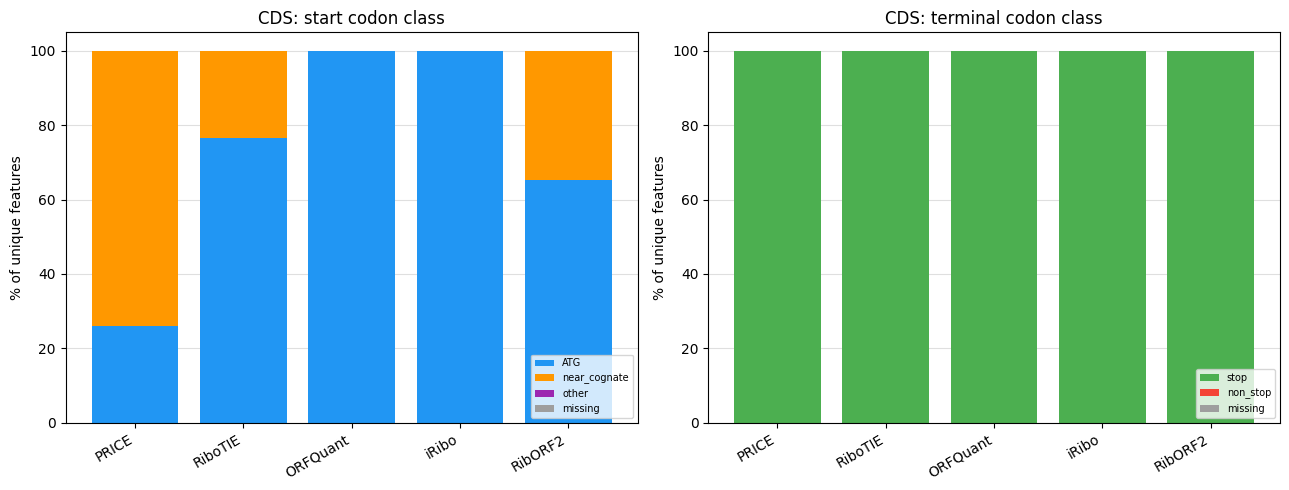

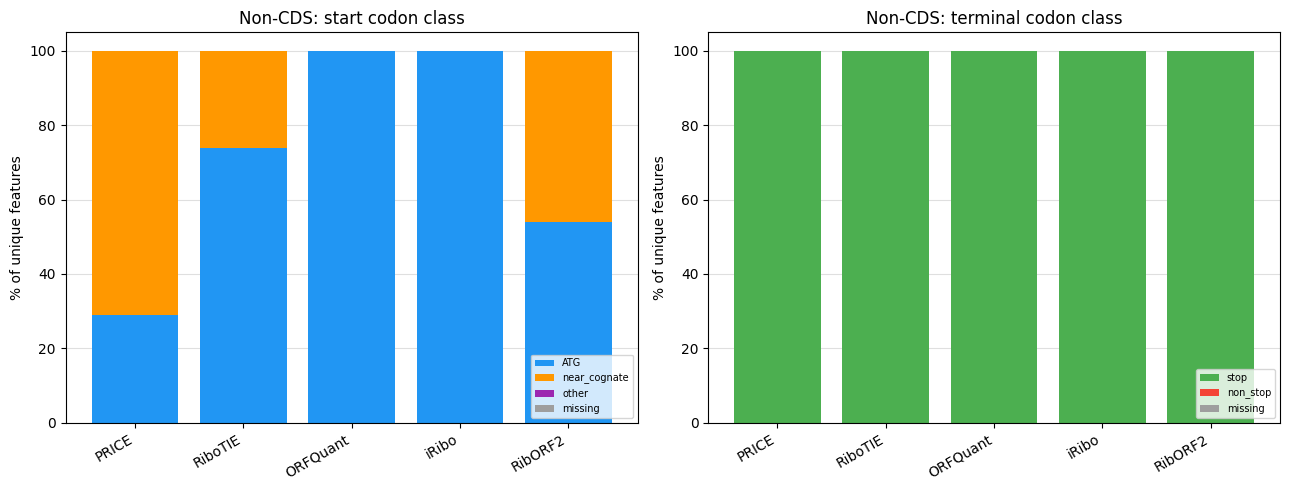

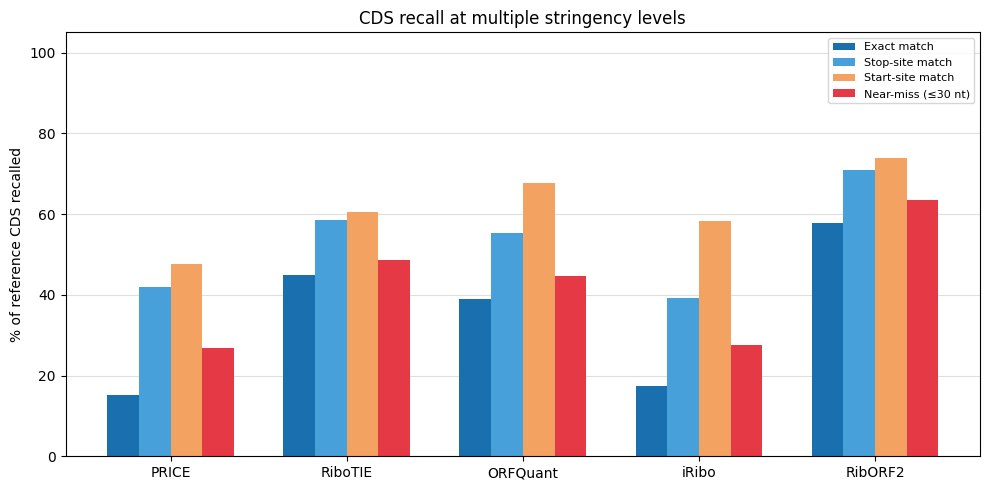

Saved cds_recall_levels.png


In [71]:
# ── Build helper keys ───────────────────────────────────────────────────────
def make_stop_key(df):
    """Unique key for the terminal end of an ORF (chrom:strand:stop_coord)."""
    stop_coord = np.where(
        df['bed_strand'] == '+',
        df['bed_end'].astype(str),
        df['bed_start'].astype(str)
    )
    return df['bed_chrom'] + ":" + df['bed_strand'] + ":" + stop_coord

def make_start_key(df):
    """Unique key for the start of an ORF (chrom:strand:start_coord)."""
    start_coord = np.where(
        df['bed_strand'] == '+',
        df['bed_start'].astype(str),
        df['bed_end'].astype(str)
    )
    return df['bed_chrom'] + ":" + df['bed_strand'] + ":" + start_coord

ref_cds = ref_cds.copy()
ref_cds['stop_key']  = make_stop_key(ref_cds)
ref_cds['start_key'] = make_start_key(ref_cds)

ref_fk_set      = set(ref_cds['feature_key'])
ref_stop_set    = set(ref_cds['stop_key'])
ref_start_set   = set(ref_cds['start_key'])
N_REF           = len(ref_fk_set)
print(f"Reference CDS: {N_REF:,} unique feature_keys")

# CDS-class features only
feats_cds = feats[feats['cls'] == 'cds'].copy()
feats_cds['stop_key']  = make_stop_key(feats_cds)
feats_cds['start_key'] = make_start_key(feats_cds)

# Per-tool recall computation
recall_records = []
for tool in TOOL_ORDER:
    sub = feats_cds[feats_cds['source_tool'] == tool]
    if sub.empty:
        continue

    # Level 1: exact match
    exact = ref_cds[ref_cds['feature_key'].isin(set(sub['feature_key']))]['feature_key'].nunique()

    # Level 2: stop-site match
    stop_match = ref_cds[ref_cds['stop_key'].isin(set(sub['stop_key']))]['feature_key'].nunique()

    # Level 3: start-site match
    start_match = ref_cds[ref_cds['start_key'].isin(set(sub['start_key']))]['feature_key'].nunique()

    # Level 4: near-miss start (shared stop, start within 30 nt)
    # Merge ref_cds with sub on stop_key
    merged = ref_cds.merge(
        sub[['stop_key', 'bed_start', 'bed_end', 'bed_strand']],
        on='stop_key', suffixes=('_ref', '_tool')
    )
    merged['start_dist'] = np.where(
        merged['bed_strand_ref'] == '+',
        (merged['bed_start_tool'] - merged['bed_start_ref']).abs(),
        (merged['bed_end_tool']   - merged['bed_end_ref']).abs()
    )
    near_miss = merged[merged['start_dist'] <= 30]['feature_key'].nunique()

    recall_records.append({
        'tool': tool,
        'Exact match':          exact / N_REF * 100,
        'Stop-site match':      stop_match / N_REF * 100,
        'Start-site match':     start_match / N_REF * 100,
        'Near-miss (≤30 nt)':   near_miss / N_REF * 100,
    })
    print(f"{tool}: exact={exact:,} ({exact/N_REF:.1%}) | stop={stop_match:,} ({stop_match/N_REF:.1%}) "
          f"| start={start_match:,} ({start_match/N_REF:.1%}) | near-miss={near_miss:,} ({near_miss/N_REF:.1%})")

recall_df = pd.DataFrame(recall_records).set_index('tool')

# ── Plot ────────────────────────────────────────────────────────────────────
LEVEL_COLORS = ['#1a6faf', '#47a0d9', '#f4a261', '#e63946']
LEVELS = ['Exact match', 'Stop-site match', 'Start-site match', 'Near-miss (≤30 nt)']

tools_present = [t for t in TOOL_ORDER if t in recall_df.index]
x = np.arange(len(tools_present))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))
for i, (level, color) in enumerate(zip(LEVELS, LEVEL_COLORS)):
    vals = [recall_df.loc[t, level] if t in recall_df.index else 0 for t in tools_present]
    ax.bar(x + i * width, vals, width, label=level, color=color)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(tools_present)
ax.set_ylabel("% of reference CDS recalled")
ax.set_title("CDS recall at multiple stringency levels")
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(OUT_DIR / "cds_recall_levels.png", dpi=180)
plt.show()
print("Saved cds_recall_levels.png")

Reference CDS missed by ALL tools (stop-site level): 27,424 / 94,931 (28.9%)

Top 10 missed CDS by spliced_length_nt (shortest):
gene_name     transcript_id  spliced_length_nt                     feature_key
    ERAP1 ENST00000503921.5                  6    chr5:96797243-96797249:-:6:0
    SMAD5 ENST00000515005.1                  6  chr5:136153760-136153766:+:6:0
     STK3 ENST00000519420.1                  6    chr8:98883750-98883756:-:6:0
   SEMA4D ENST00000420670.5                  6    chr9:89405450-89405456:-:6:0
     MRLN ENST00000602051.5                  6   chr10:59737194-59737200:-:6:0
     MRLN ENST00000599605.1                  6   chr10:59737194-59737200:-:6:0
   SLC1A2 ENST00000645966.1                  6   chr11:35317500-35317506:-:6:0
    TENM4 ENST00000527736.5                  6   chr11:79069938-79069944:-:6:0
    TIRAP ENST00000467006.6                  6 chr11:126290894-126290900:+:6:0
    SCN8A ENST00000546961.1                  6   chr12:51662817-51662823:+:6:0


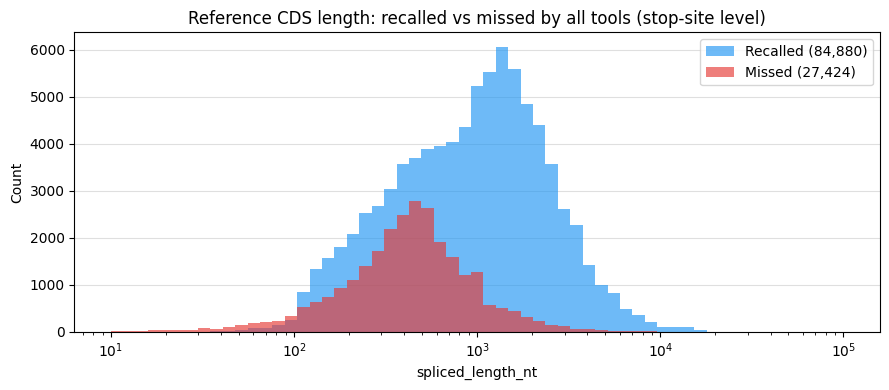

Saved cds_missed_length_hist.png


In [72]:
# ── Which reference CDS are missed by all tools? ───────────────────────────
all_tool_stop_keys = set(feats_cds['stop_key'])
missed_mask = ~ref_cds['stop_key'].isin(all_tool_stop_keys)
missed_cds  = ref_cds[missed_mask].copy()
recalled_cds = ref_cds[~missed_mask].copy()

print(f"Reference CDS missed by ALL tools (stop-site level): {len(missed_cds):,} / {N_REF:,} "
      f"({len(missed_cds)/N_REF:.1%})")

print("\nTop 10 missed CDS by spliced_length_nt (shortest):")
print(missed_cds.nsmallest(10, 'spliced_length_nt')[[
    'gene_name', 'transcript_id', 'spliced_length_nt', 'feature_key'
]].to_string(index=False))

# ── Histogram: spliced_length_nt recalled vs missed ────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(1, 5, 60)
ax.hist(recalled_cds['spliced_length_nt'].dropna(), bins=bins,
        color='#2196F3', alpha=0.65, label=f"Recalled ({len(recalled_cds):,})")
ax.hist(missed_cds['spliced_length_nt'].dropna(),   bins=bins,
        color='#E53935', alpha=0.65, label=f"Missed ({len(missed_cds):,})")
ax.set_xscale('log')
ax.set_xlabel("spliced_length_nt")
ax.set_ylabel("Count")
ax.set_title("Reference CDS length: recalled vs missed by all tools (stop-site level)")
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(OUT_DIR / "cds_missed_length_hist.png", dpi=180)
plt.show()
print("Saved cds_missed_length_hist.png")

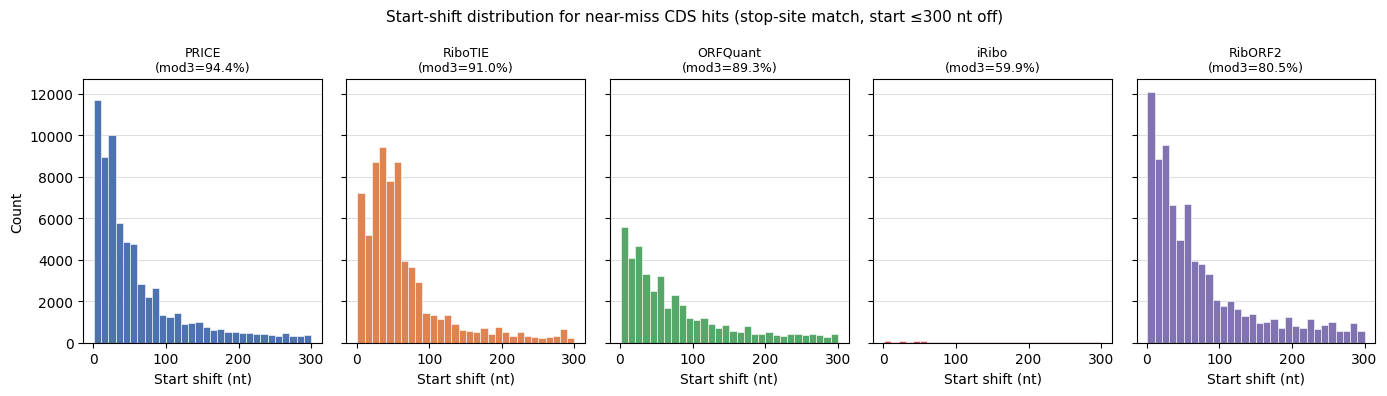

Saved start_shift_distribution.png


In [73]:
# ── Start-shift distribution for near-miss hits ────────────────────────────
fig, axes = plt.subplots(1, len(TOOL_ORDER), figsize=(14, 4), sharey=True)

for ax, tool in zip(axes, TOOL_ORDER):
    sub = feats_cds[feats_cds['source_tool'] == tool]
    if sub.empty:
        ax.set_title(tool)
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    merged = ref_cds.merge(
        sub[['stop_key', 'bed_start', 'bed_end', 'bed_strand', 'feature_key']],
        on='stop_key', suffixes=('_ref', '_tool')
    )
    # Keep only near-misses: same stop, different start, shift ≤300 nt
    merged['start_dist'] = np.where(
        merged['bed_strand_ref'] == '+',
        (merged['bed_start_tool'] - merged['bed_start_ref']).abs(),
        (merged['bed_end_tool']   - merged['bed_end_ref']).abs()
    )
    near = merged[(merged['start_dist'] > 0) & (merged['start_dist'] <= 300)]

    if near.empty:
        ax.set_title(tool)
        ax.text(0.5, 0.5, 'No near-misses', ha='center', va='center', transform=ax.transAxes)
        continue

    dists = near['start_dist'].values
    mod3_frac = (dists % 3 == 0).mean()

    ax.hist(dists, bins=30, color=TOOL_COLORS.get(tool, '#888'), edgecolor='white', linewidth=0.4)
    ax.set_title(f"{tool}\n(mod3={mod3_frac:.1%})", fontsize=9)
    ax.set_xlabel("Start shift (nt)")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle("Start-shift distribution for near-miss CDS hits (stop-site match, start ≤300 nt off)",
             fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / "start_shift_distribution.png", dpi=180)
plt.show()
print("Saved start_shift_distribution.png")

## Cross-tool concordance

Examining how much the tools agree on novel (non-CDS) ORF calls.

Non-CDS feature_keys by tool support tier:
n_tools
1    183268
2     31153
3      9634
4      2981
5       429
Name: count, dtype: int64


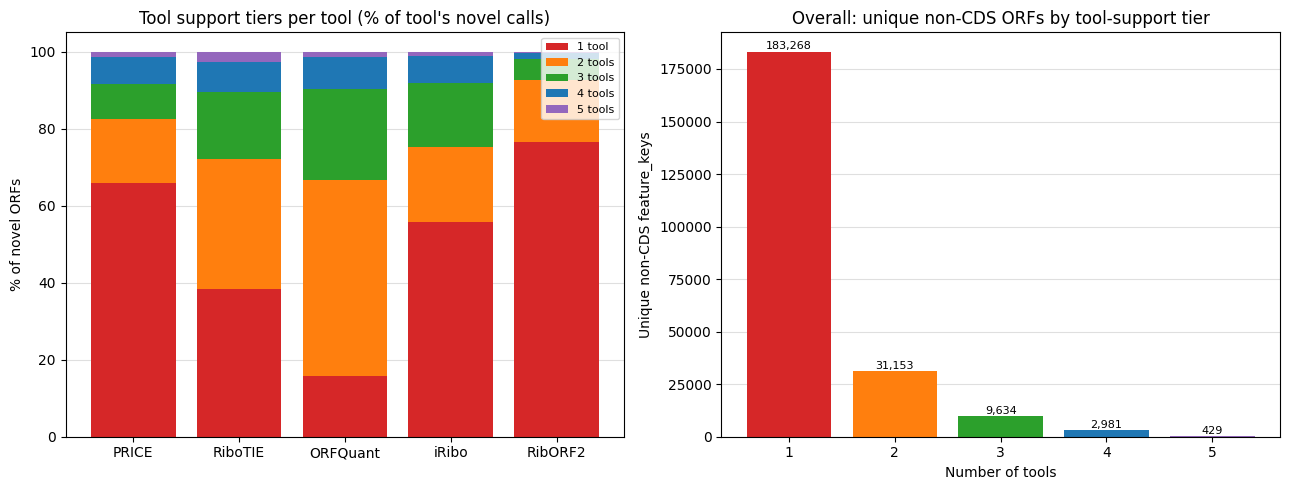

Saved tool_support_tiers.png


In [74]:
# ── Tool support tiers for novel ORFs ──────────────────────────────────────
novel = feats[feats['cls'] == 'non_cds'].copy()

# Number of tools supporting each feature_key
support_counts = (novel.groupby('feature_key')['source_tool']
                       .nunique()
                       .rename('n_tools'))

# Overall distribution
overall_dist = support_counts.value_counts().sort_index()
print("Non-CDS feature_keys by tool support tier:")
print(overall_dist)

# For each tool: per-support-tier breakdown of its own calls
novel_with_support = novel.merge(support_counts.reset_index(), on='feature_key')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: per-tool stacked bar (fraction)
ax = axes[0]
tier_colors = {1: '#d62728', 2: '#ff7f0e', 3: '#2ca02c', 4: '#1f77b4', 5: '#9467bd'}
tools_present = [t for t in TOOL_ORDER if t in novel_with_support['source_tool'].values]

bottom = np.zeros(len(tools_present))
for tier in range(1, 6):
    fracs = []
    for t in tools_present:
        sub = novel_with_support[novel_with_support['source_tool'] == t]
        total = sub['feature_key'].nunique()
        frac  = sub[sub['n_tools'] == tier]['feature_key'].nunique() / max(total, 1)
        fracs.append(frac * 100)
    ax.bar(tools_present, fracs, bottom=bottom,
           color=tier_colors.get(tier, '#aaa'), label=f"{tier} tool{'s' if tier > 1 else ''}")
    bottom += np.array(fracs)

ax.set_ylabel("% of novel ORFs")
ax.set_title("Tool support tiers per tool (% of tool's novel calls)")
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Panel B: overall distribution (absolute counts)
ax2 = axes[1]
tiers = overall_dist.index.tolist()
counts = overall_dist.values
bars = ax2.bar([str(t) for t in tiers], counts,
               color=[tier_colors.get(t, '#aaa') for t in tiers])
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{count:,}", ha='center', va='bottom', fontsize=8)
ax2.set_xlabel("Number of tools")
ax2.set_ylabel("Unique non-CDS feature_keys")
ax2.set_title("Overall: unique non-CDS ORFs by tool-support tier")
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
fig.savefig(OUT_DIR / "tool_support_tiers.png", dpi=180)
plt.show()
print("Saved tool_support_tiers.png")

Pairwise Jaccard similarity (non-CDS feature_keys):
          PRICE  RiboTIE  ORFQuant  iRibo  RibORF2
PRICE     1.000    0.034     0.074  0.061    0.053
RiboTIE   0.034    1.000     0.086  0.044    0.050
ORFQuant  0.074    0.086     1.000  0.162    0.139
iRibo     0.061    0.044     0.162  1.000    0.064
RibORF2   0.053    0.050     0.139  0.064    1.000


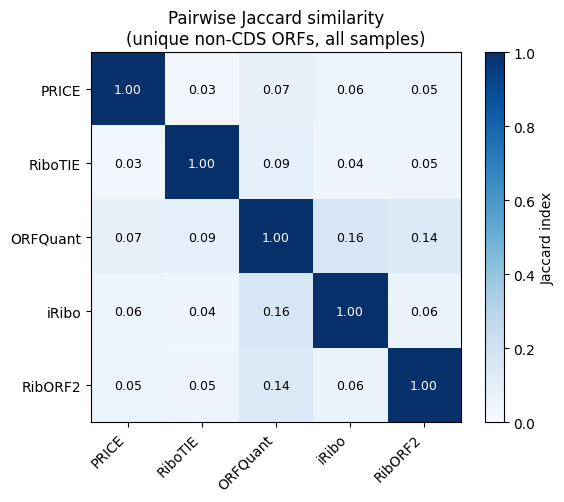

Saved jaccard_heatmap.png


In [75]:
# ── Pairwise Jaccard similarity (novel ORFs) ───────────────────────────────
tools_present = [t for t in TOOL_ORDER if t in novel['source_tool'].values]
tool_sets = {
    t: set(novel[novel['source_tool'] == t]['feature_key'])
    for t in tools_present
}

n = len(tools_present)
jaccard_mat = np.zeros((n, n))
for i, t1 in enumerate(tools_present):
    for j, t2 in enumerate(tools_present):
        s1, s2 = tool_sets[t1], tool_sets[t2]
        inter = len(s1 & s2)
        union = len(s1 | s2)
        jaccard_mat[i, j] = inter / union if union > 0 else 0.0

print("Pairwise Jaccard similarity (non-CDS feature_keys):")
print(pd.DataFrame(jaccard_mat, index=tools_present, columns=tools_present).round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jaccard_mat, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tools_present, rotation=45, ha='right')
ax.set_yticklabels(tools_present)
ax.set_title("Pairwise Jaccard similarity\n(unique non-CDS ORFs, all samples)")
plt.colorbar(im, ax=ax, label="Jaccard index")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{jaccard_mat[i,j]:.2f}",
                ha='center', va='center', fontsize=9,
                color='white' if jaccard_mat[i, j] > 0.6 else 'black')
plt.tight_layout()
fig.savefig(OUT_DIR / "jaccard_heatmap.png", dpi=180)
plt.show()
print("Saved jaccard_heatmap.png")

## Cell-type and sample analysis

Exploring the overlap of novel ORFs across pancreas, fibroblast, and endothelial cell types,
and the contribution of individual vs pooled samples.

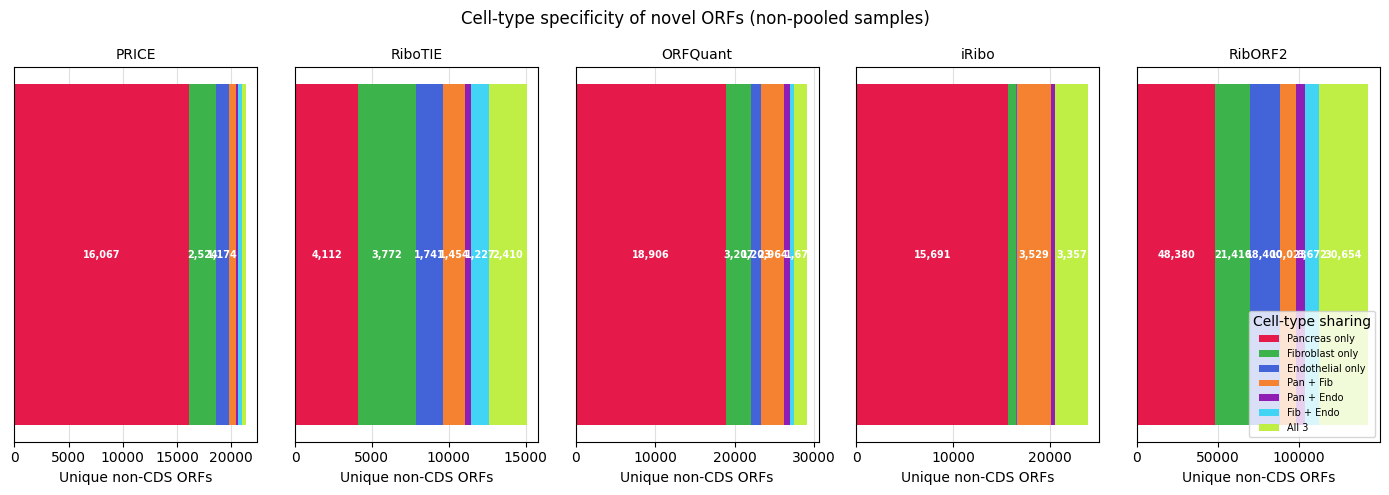

Saved celltype_specificity.png


In [76]:
# ── Cell-type specificity of novel ORFs (non-pooled samples only) ──────────
con = sqlite3.connect(DB)
novel_samples = pd.read_sql_query(f"""
    SELECT source_tool, sample_id, feature_key
    FROM translons
    WHERE {BASE_FILTER} AND source_feature_class = 'non_cds'
    GROUP BY source_tool, sample_id, feature_key
""", con)
con.close()

# Exclude pooled samples
novel_samples = novel_samples[~novel_samples['sample_id'].isin(POOLED_SAMPLES)].copy()
novel_samples['cell_type'] = novel_samples['sample_id'].map(SAMPLE_CELL_TYPE)
novel_samples = novel_samples.dropna(subset=['cell_type'])

CELL_TYPES = ['pancreas', 'fibroblast', 'endothelial']
CT_COLORS  = {'pancreas': '#e6194b', 'fibroblast': '#3cb44b', 'endothelial': '#4363d8'}

tools_present = [t for t in TOOL_ORDER if t in novel_samples['source_tool'].values]

CATEGORY_LABELS = [
    'Pancreas only', 'Fibroblast only', 'Endothelial only',
    'Pan + Fib', 'Pan + Endo', 'Fib + Endo', 'All 3'
]
CAT_COLORS = [
    '#e6194b', '#3cb44b', '#4363d8',
    '#f58231', '#911eb4', '#42d4f4', '#bfef45'
]

fig, axes = plt.subplots(1, len(tools_present), figsize=(14, 5), sharey=False)
if len(tools_present) == 1:
    axes = [axes]

for ax, tool in zip(axes, tools_present):
    sub = novel_samples[novel_samples['source_tool'] == tool]
    ct_sets = {
        ct: set(sub[sub['cell_type'] == ct]['feature_key'])
        for ct in CELL_TYPES
    }
    P, F, E = ct_sets['pancreas'], ct_sets['fibroblast'], ct_sets['endothelial']

    counts = [
        len(P - F - E),               # Pancreas only
        len(F - P - E),               # Fibroblast only
        len(E - P - F),               # Endothelial only
        len((P & F) - E),             # Pan + Fib
        len((P & E) - F),             # Pan + Endo
        len((F & E) - P),             # Fib + Endo
        len(P & F & E),               # All 3
    ]
    total = sum(counts)

    # Horizontal stacked bar
    left = 0
    for count, color, label in zip(counts, CAT_COLORS, CATEGORY_LABELS):
        ax.barh([0], [count], left=left, color=color, label=label)
        if count > total * 0.04:
            ax.text(left + count / 2, 0, f"{count:,}",
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold')
        left += count

    ax.set_title(tool, fontsize=10)
    ax.set_yticks([])
    ax.set_xlabel("Unique non-CDS ORFs")
    ax.xaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

axes[-1].legend(loc='lower right', fontsize=7, title="Cell-type sharing")
fig.suptitle("Cell-type specificity of novel ORFs (non-pooled samples)", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "celltype_specificity.png", dpi=180)
plt.show()
print("Saved celltype_specificity.png")

        tool             cell_type  pooled_only  shared  individual_only
0      PRICE  Ribo_Pancreas_pooled            0       0                0
1      PRICE       Ribo_Fib_pooled            0       0                0
2      PRICE        Ribo_EC_pooled            0       0                0
3    RiboTIE  Ribo_Pancreas_pooled            0       0                0
4    RiboTIE       Ribo_Fib_pooled            0       0                0
5    RiboTIE        Ribo_EC_pooled            0       0                0
6   ORFQuant  Ribo_Pancreas_pooled            0       0                0
7   ORFQuant       Ribo_Fib_pooled            0       0                0
8   ORFQuant        Ribo_EC_pooled            0       0                0
9      iRibo  Ribo_Pancreas_pooled            0       0                0
10     iRibo       Ribo_Fib_pooled            0       0                0
11     iRibo        Ribo_EC_pooled            0       0                0
12   RibORF2  Ribo_Pancreas_pooled            0    

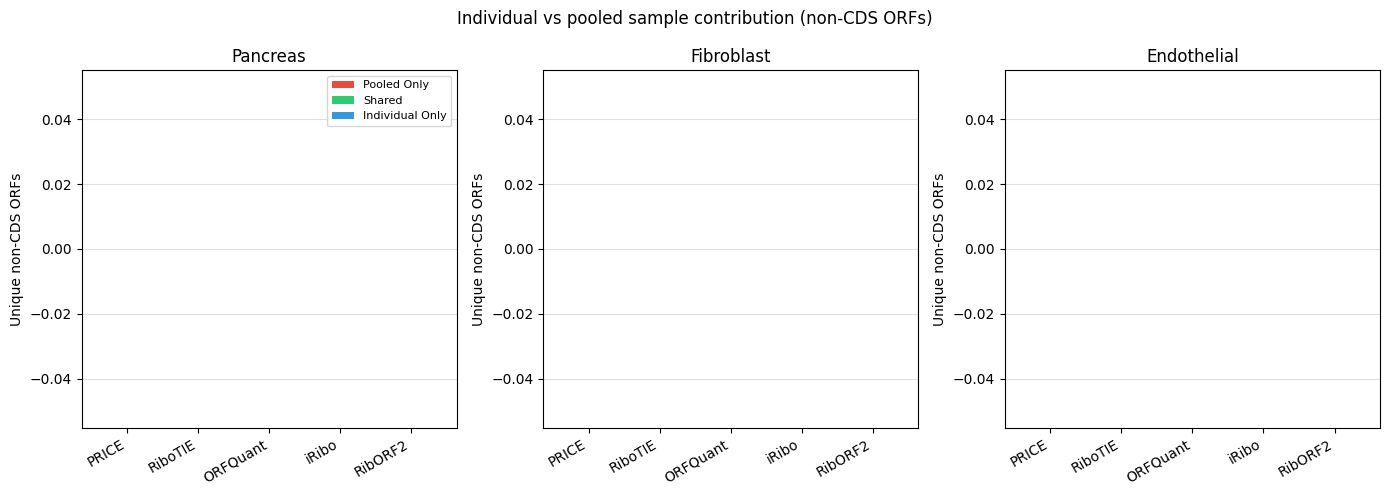

Saved individual_vs_pooled.png


In [77]:
# ── Individual vs pooled: what does pooling add? ───────────────────────────
# Map each pooled sample to its cell type
POOLED_CT = {
    'Ribo_Pancreas_pooled': 'pancreas',
    'Ribo_Fib_pooled':      'fibroblast',
    'Ribo_EC_pooled':       'endothelial',
}

con = sqlite3.connect(DB)
novel_all = pd.read_sql_query(f"""
    SELECT source_tool, sample_id, feature_key
    FROM translons
    WHERE {BASE_FILTER} AND source_feature_class = 'non_cds'
    GROUP BY source_tool, sample_id, feature_key
""", con)
con.close()

novel_all['cell_type'] = novel_all['sample_id'].map(SAMPLE_CELL_TYPE)
novel_all = novel_all.dropna(subset=['cell_type'])

pooling_records = []
for tool in TOOL_ORDER:
    sub = novel_all[novel_all['source_tool'] == tool]
    if sub.empty:
        continue
    for ct, pooled_sid in POOLED_CT.items():
        indiv = sub[(sub['cell_type'] == ct) & (~sub['sample_id'].isin(POOLED_SAMPLES))]
        pooled = sub[sub['sample_id'] == pooled_sid]
        indiv_set  = set(indiv['feature_key'])
        pooled_set = set(pooled['feature_key'])
        pooling_records.append({
            'tool': tool, 'cell_type': ct,
            'pooled_only':     len(pooled_set - indiv_set),
            'shared':          len(pooled_set & indiv_set),
            'individual_only': len(indiv_set  - pooled_set),
        })

pool_df = pd.DataFrame(pooling_records)
print(pool_df)

# Stacked bar per tool × cell_type
tools_present = [t for t in TOOL_ORDER if t in pool_df['tool'].values]
fig, axes = plt.subplots(1, len(CELL_TYPES), figsize=(14, 5), sharey=False)

for ax, ct in zip(axes, CELL_TYPES):
    sub = pool_df[pool_df['cell_type'] == ct]
    x = np.arange(len(tools_present))
    bot = np.zeros(len(tools_present))
    stack_cols = {'pooled_only': '#e74c3c', 'shared': '#2ecc71', 'individual_only': '#3498db'}
    for col, color in stack_cols.items():
        vals = [sub[sub['tool'] == t][col].values[0] if t in sub['tool'].values else 0
                for t in tools_present]
        ax.bar(x, vals, bottom=bot, color=color, label=col.replace('_', ' ').title())
        bot += np.array(vals)
    ax.set_xticks(x)
    ax.set_xticklabels(tools_present, rotation=30, ha='right')
    ax.set_title(ct.capitalize())
    ax.set_ylabel("Unique non-CDS ORFs")
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=8)

fig.suptitle("Individual vs pooled sample contribution (non-CDS ORFs)", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "individual_vs_pooled.png", dpi=180)
plt.show()
print("Saved individual_vs_pooled.png")

    tool   cell_type  n_samples  n_features    f_ge2
   PRICE    pancreas          6       17255 0.318227
   PRICE  fibroblast         10        3910 0.310997
   PRICE endothelial          6        2103 0.226343
 RiboTIE    pancreas          6        8321 0.560510
 RiboTIE  fibroblast         10        8863 0.517883
 RiboTIE endothelial          6        5723 0.433339
ORFQuant    pancreas          6       24260 0.537057
ORFQuant  fibroblast         10        8315 0.422971
ORFQuant endothelial          6        4066 0.300787
   iRibo    pancreas          6       22977 0.711451
   iRibo  fibroblast         10        7706 0.714378
   iRibo endothelial          6        3932 0.598678
 RibORF2    pancreas          6       94157 0.701881
 RibORF2  fibroblast         10       70765 0.629916
 RibORF2 endothelial          6       62826 0.520692


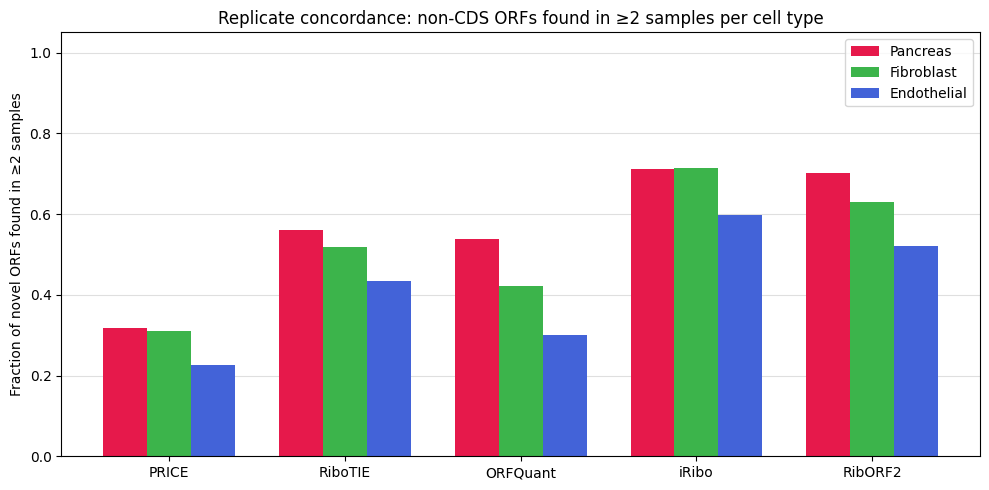

Saved replicate_concordance.png


In [78]:
# ── Replicate concordance (novel ORFs, non-pooled) ─────────────────────────
indiv_novel = novel_samples.copy()  # already filtered to non-pooled, has cell_type col

tools_present = [t for t in TOOL_ORDER if t in indiv_novel['source_tool'].values]
repro_records = []

for tool in tools_present:
    for ct in CELL_TYPES:
        sub = indiv_novel[(indiv_novel['source_tool'] == tool) & (indiv_novel['cell_type'] == ct)]
        if sub.empty:
            continue
        n_samples = sub['sample_id'].nunique()
        per_fk = sub.groupby('feature_key')['sample_id'].nunique().rename('n_samples_seen')
        total = len(per_fk)
        if total == 0:
            continue
        f_ge1 = (per_fk >= 1).sum() / total
        f_ge2 = (per_fk >= 2).sum() / total if n_samples >= 2 else np.nan
        f_ge3 = (per_fk >= 3).sum() / total if n_samples >= 3 else np.nan
        repro_records.append({
            'tool': tool, 'cell_type': ct,
            'n_samples': n_samples, 'n_features': total,
            'f_ge1': f_ge1, 'f_ge2': f_ge2, 'f_ge3': f_ge3
        })

repro_df = pd.DataFrame(repro_records)
print(repro_df[['tool', 'cell_type', 'n_samples', 'n_features', 'f_ge2']].to_string(index=False))

# Plot: fraction found in ≥2 samples, grouped by cell type
CT_COLORS_LIST = [CT_COLORS[ct] for ct in CELL_TYPES]
x = np.arange(len(tools_present))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (ct, color) in enumerate(zip(CELL_TYPES, CT_COLORS_LIST)):
    sub = repro_df[repro_df['cell_type'] == ct]
    vals = [sub[sub['tool'] == t]['f_ge2'].values[0]
            if t in sub['tool'].values else np.nan
            for t in tools_present]
    ax.bar(x + i * width, vals, width, color=color, label=ct.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(tools_present)
ax.set_ylabel("Fraction of novel ORFs found in ≥2 samples")
ax.set_title("Replicate concordance: non-CDS ORFs found in ≥2 samples per cell type")
ax.set_ylim(0, 1.05)
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(OUT_DIR / "replicate_concordance.png", dpi=180)
plt.show()
print("Saved replicate_concordance.png")

## ORF endpoint analysis

Examining shared stop sites and alternative start sites among novel ORFs.

Stop site summary (non-CDS ORFs):
             n_tools       n_starts
count  109586.000000  109586.000000
mean        1.619623       2.030314
std         0.936611       1.798087
min         1.000000       1.000000
25%         1.000000       1.000000
50%         1.000000       1.000000
75%         2.000000       2.000000
max         5.000000      45.000000

Stop sites shared by ≥2 tools: 41,816
Stop sites with ≥2 distinct starts: 48,867


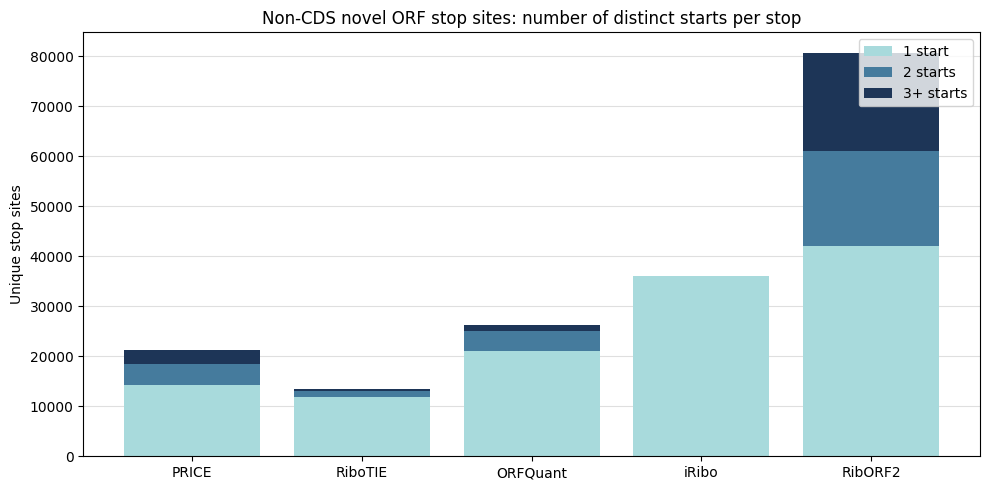

Saved stop_site_start_counts.png


In [79]:
# ── Stop-site sharing between tools ───────────────────────────────────────
novel_w_keys = novel.copy()
novel_w_keys['stop_key']  = make_stop_key(novel_w_keys)
novel_w_keys['start_key'] = make_start_key(novel_w_keys)

# For each stop_key: how many tools call at least one ORF there?
stop_tool_count = (novel_w_keys.groupby('stop_key')['source_tool']
                               .nunique()
                               .rename('n_tools'))

# For each stop_key: how many distinct starts?
stop_start_count = (novel_w_keys.groupby('stop_key')['start_key']
                                .nunique()
                                .rename('n_starts'))

stop_summary = pd.concat([stop_tool_count, stop_start_count], axis=1)
print("Stop site summary (non-CDS ORFs):")
print(stop_summary.describe())
print(f"\nStop sites shared by ≥2 tools: {(stop_summary['n_tools'] >= 2).sum():,}")
print(f"Stop sites with ≥2 distinct starts: {(stop_summary['n_starts'] >= 2).sum():,}")

# Stacked bar: stops categorised by n_starts, for those shared by ≥2 tools, per tool pair
# Simplified: per-tool breakdown of stop sites with 1, 2, 3+ starts
fig, ax = plt.subplots(figsize=(10, 5))
tools_present = [t for t in TOOL_ORDER if t in novel_w_keys['source_tool'].values]
x = np.arange(len(tools_present))
n_starts_colors = {1: '#a8dadc', 2: '#457b9d', '3+': '#1d3557'}

bot = np.zeros(len(tools_present))
for cat, color in n_starts_colors.items():
    vals = []
    for t in tools_present:
        sub = novel_w_keys[novel_w_keys['source_tool'] == t]
        stops = sub.groupby('stop_key')['start_key'].nunique().rename('n_starts')
        if cat == '3+':
            v = (stops >= 3).sum()
        else:
            v = (stops == cat).sum()
        vals.append(v)
    label = f"{cat} start{'s' if cat != 1 else ''}"
    ax.bar(x, vals, bottom=bot, color=color, label=label)
    bot += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels(tools_present)
ax.set_ylabel("Unique stop sites")
ax.set_title("Non-CDS novel ORF stop sites: number of distinct starts per stop")
ax.legend(loc='upper right')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(OUT_DIR / "stop_site_start_counts.png", dpi=180)
plt.show()
print("Saved stop_site_start_counts.png")

Multi-start groups — CDS: 59,477 | non-CDS: 48,867


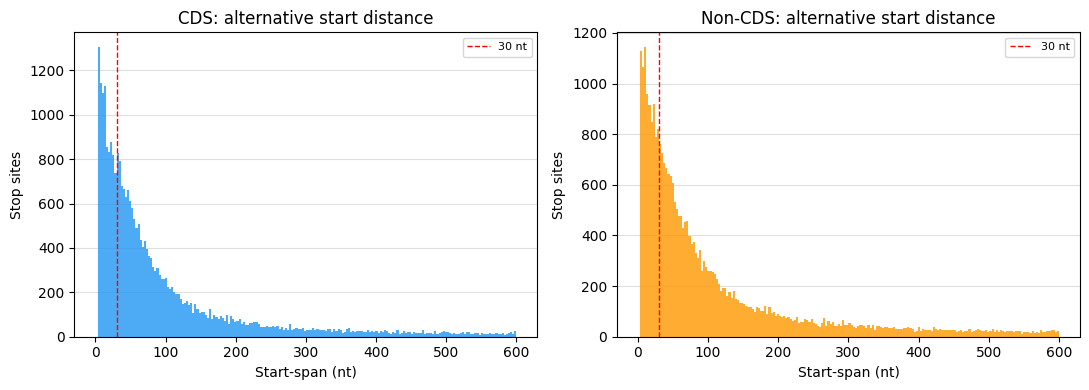

Saved alt_start_distance.png


In [80]:
# ── Alternative start distance at shared stops ─────────────────────────────
# Include both CDS and non-CDS
all_feats_w_keys = feats.copy()
all_feats_w_keys['stop_key']  = make_stop_key(all_feats_w_keys)
all_feats_w_keys['start_key'] = make_start_key(all_feats_w_keys)

# Groups with >1 distinct start
multi_start_stops = (
    all_feats_w_keys.groupby(['cls', 'stop_key'])
    .filter(lambda g: g['start_key'].nunique() > 1)
)

span_records = []
for (cls, stop_key), grp in multi_start_stops.groupby(['cls', 'stop_key']):
    if grp['bed_strand'].iloc[0] == '+':
        span = grp['bed_start'].max() - grp['bed_start'].min()
    else:
        span = grp['bed_end'].max() - grp['bed_end'].min()
    span_records.append({'cls': cls, 'span_nt': span})

span_df = pd.DataFrame(span_records)
print(f"Multi-start groups — CDS: {(span_df['cls']=='cds').sum():,} | non-CDS: {(span_df['cls']=='non_cds').sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
bins = np.arange(0, 603, 3)  # 3-nt bins
for ax, cls in zip(axes, CLS_ORDER):
    sub = span_df[span_df['cls'] == cls]['span_nt']
    sub_clipped = sub[sub <= 600]
    ax.hist(sub_clipped, bins=bins, color=CLS_COLORS[cls], edgecolor='none', alpha=0.8)
    ax.set_xlabel("Start-span (nt)")
    ax.set_ylabel("Stop sites")
    ax.set_title(f"{CLS_LABELS[cls]}: alternative start distance")
    ax.axvline(30, color='red', linestyle='--', lw=1, label='30 nt')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(OUT_DIR / "alt_start_distance.png", dpi=180)
plt.show()
print("Saved alt_start_distance.png")

## ORF structure

Mono-exon vs multi-exon, spliced length distributions, and codon profiles.

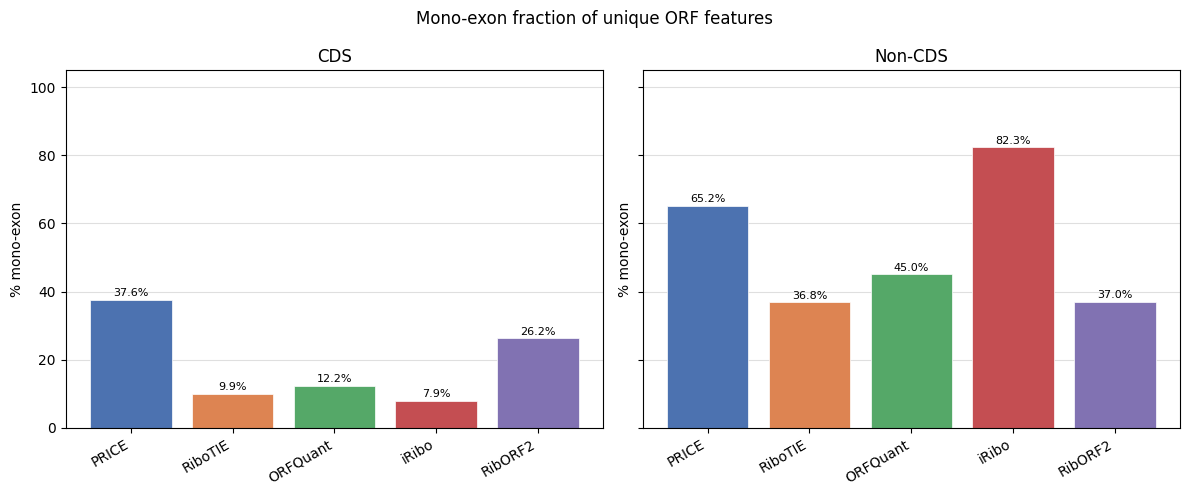

Saved mono_exon_fraction.png


In [81]:
# ── Mono-exon vs multi-exon breakdown ──────────────────────────────────────
tools_present = [t for t in TOOL_ORDER if t in feats['source_tool'].values]
x = np.arange(len(tools_present))
width = 0.35

fig, axes = plt.subplots(1, len(CLS_ORDER), figsize=(12, 5), sharey=True)

for ax, cls in zip(axes, CLS_ORDER):
    sub = feats[feats['cls'] == cls]
    mono_fracs = []
    for t in tools_present:
        tsub = sub[sub['source_tool'] == t]
        total = len(tsub)
        mono  = (tsub['block_count'] == 1).sum()
        mono_fracs.append(mono / total * 100 if total > 0 else 0)

    bars = ax.bar(x, mono_fracs,
                  color=[TOOL_COLORS.get(t, '#888') for t in tools_present],
                  edgecolor='white', linewidth=0.5)
    for bar, frac in zip(bars, mono_fracs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5, f"{frac:.1f}%",
                ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(tools_present, rotation=30, ha='right')
    ax.set_ylabel("% mono-exon")
    ax.set_title(CLS_LABELS[cls])
    ax.set_ylim(0, 105)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle("Mono-exon fraction of unique ORF features", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "mono_exon_fraction.png", dpi=180)
plt.show()
print("Saved mono_exon_fraction.png")

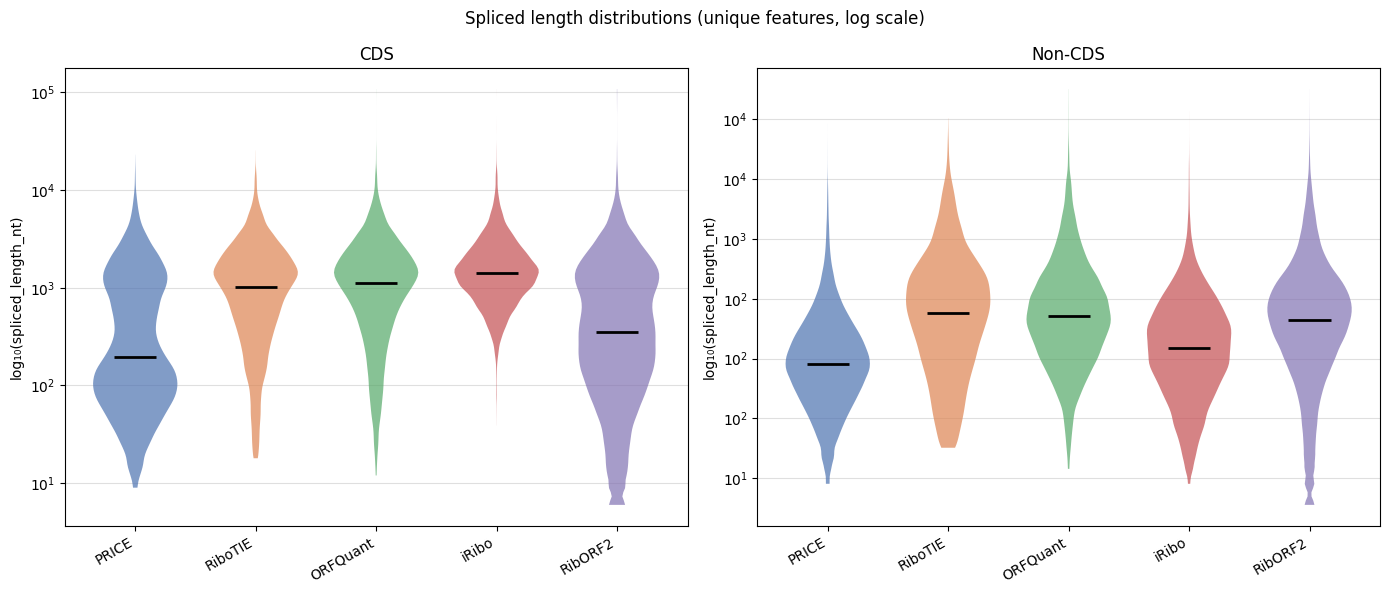

Saved spliced_length_violins.png


In [82]:
# ── Spliced length distributions ───────────────────────────────────────────
tools_present = [t for t in TOOL_ORDER if t in feats['source_tool'].values]

fig, axes = plt.subplots(1, len(CLS_ORDER), figsize=(14, 6))

def violin_from_data(ax, data_list, positions, colors, widths=0.7):
    """Minimal violin plot using matplotlib."""
    for pos, data, color in zip(positions, data_list, colors):
        data_clean = np.array(data).astype(float)
        data_clean = data_clean[np.isfinite(data_clean) & (data_clean > 0)]
        if len(data_clean) < 5:
            ax.scatter([pos], [np.median(data_clean)] if len(data_clean) > 0 else [1],
                       color=color, zorder=3)
            continue
        log_data = np.log10(data_clean)
        parts = ax.violinplot([log_data], positions=[pos], widths=widths,
                              showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(2)

for ax, cls in zip(axes, CLS_ORDER):
    sub = feats[feats['cls'] == cls]
    data_list = [sub[sub['source_tool'] == t]['spliced_length_nt'].dropna().values
                 for t in tools_present]
    colors     = [TOOL_COLORS.get(t, '#888') for t in tools_present]
    positions  = list(range(1, len(tools_present) + 1))

    violin_from_data(ax, data_list, positions, colors)

    ax.set_xticks(positions)
    ax.set_xticklabels(tools_present, rotation=30, ha='right')
    ax.set_ylabel("log₁₀(spliced_length_nt)")
    ax.set_title(CLS_LABELS[cls])
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

    # Add actual tick labels
    yticks = ax.get_yticks()
    ax.set_yticklabels([f"$10^{{{y:.0f}}}$" for y in yticks])

fig.suptitle("Spliced length distributions (unique features, log scale)", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "spliced_length_violins.png", dpi=180)
plt.show()
print("Saved spliced_length_violins.png")

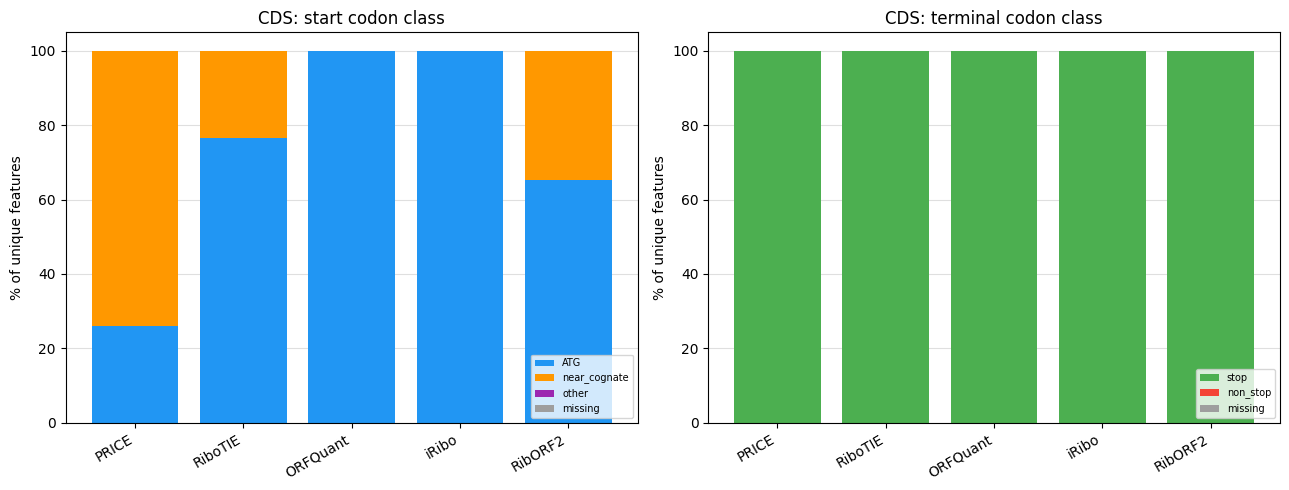

Saved codon_profiles_cds.png


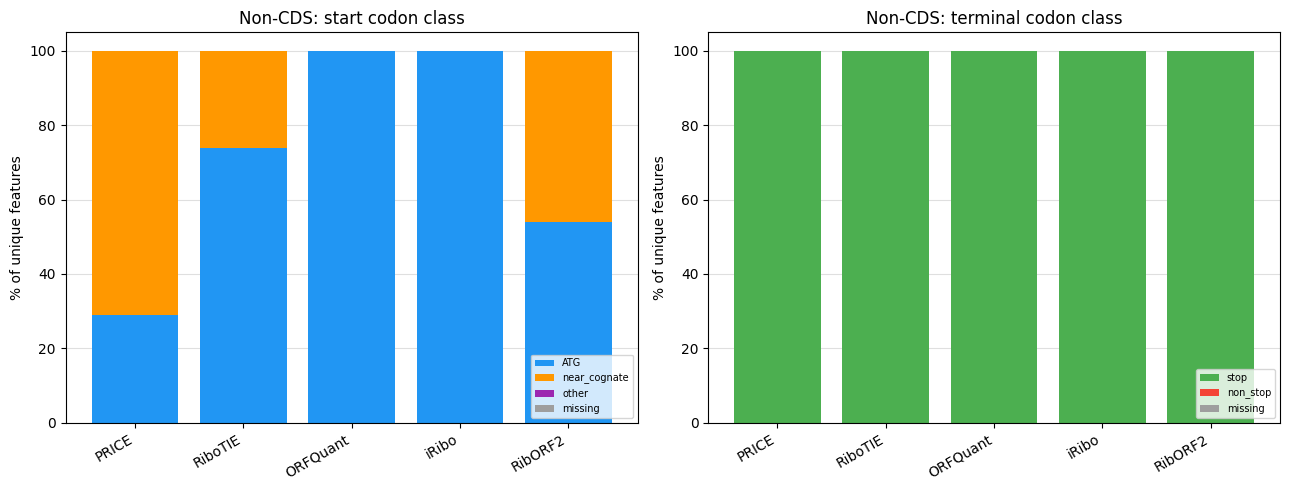

Saved codon_profiles_non_cds.png

All figures saved to: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures


In [83]:
# ── Start and terminal codon profiles ──────────────────────────────────────
tools_present = [t for t in TOOL_ORDER if t in feats['source_tool'].values]

# Map codon classes to ordered display categories
START_CATS    = ['ATG', 'near_cognate', 'other', 'missing']
TERMINAL_CATS = ['stop', 'non_stop', 'missing']

START_COLORS    = ['#2196F3', '#FF9800', '#9C27B0', '#9E9E9E']
TERMINAL_COLORS = ['#4CAF50', '#F44336', '#9E9E9E']

def codon_profile_plot(ax, feats_sub, col, cats, colors, title):
    x = np.arange(len(tools_present))
    bot = np.zeros(len(tools_present))
    for cat, color in zip(cats, colors):
        fracs = []
        for t in tools_present:
            tsub = feats_sub[feats_sub['source_tool'] == t]
            total = len(tsub)
            n = (tsub[col].fillna('missing') == cat).sum()
            fracs.append(n / total * 100 if total > 0 else 0)
        ax.bar(x, fracs, bottom=bot, color=color, label=cat)
        bot += np.array(fracs)
    ax.set_xticks(x)
    ax.set_xticklabels(tools_present, rotation=30, ha='right')
    ax.set_ylim(0, 105)
    ax.set_title(title)
    ax.set_ylabel("% of unique features")
    ax.legend(loc='lower right', fontsize=7)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

for cls in CLS_ORDER:
    feats_sub = feats[feats['cls'] == cls]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    codon_profile_plot(axes[0], feats_sub, 'start_codon_class',
                       START_CATS, START_COLORS,
                       f"{CLS_LABELS[cls]}: start codon class")
    codon_profile_plot(axes[1], feats_sub, 'terminal_codon_class',
                       TERMINAL_CATS, TERMINAL_COLORS,
                       f"{CLS_LABELS[cls]}: terminal codon class")

    # Flag non-stop terminal codons
    non_stop_frac = (feats_sub['terminal_codon_class'] != 'stop').mean()
    if non_stop_frac > 0.01:
        print(f"WARNING: {cls} has {non_stop_frac:.1%} non-stop terminal codons — check QC filters!")

    plt.tight_layout()
    fname = OUT_DIR / f"codon_profiles_{cls}.png"
    fig.savefig(fname, dpi=180)
    plt.show()
    print(f"Saved {fname.name}")

print("\nAll figures saved to:", OUT_DIR.resolve())